# Parallel Computing Figures

##### AllReduce

- 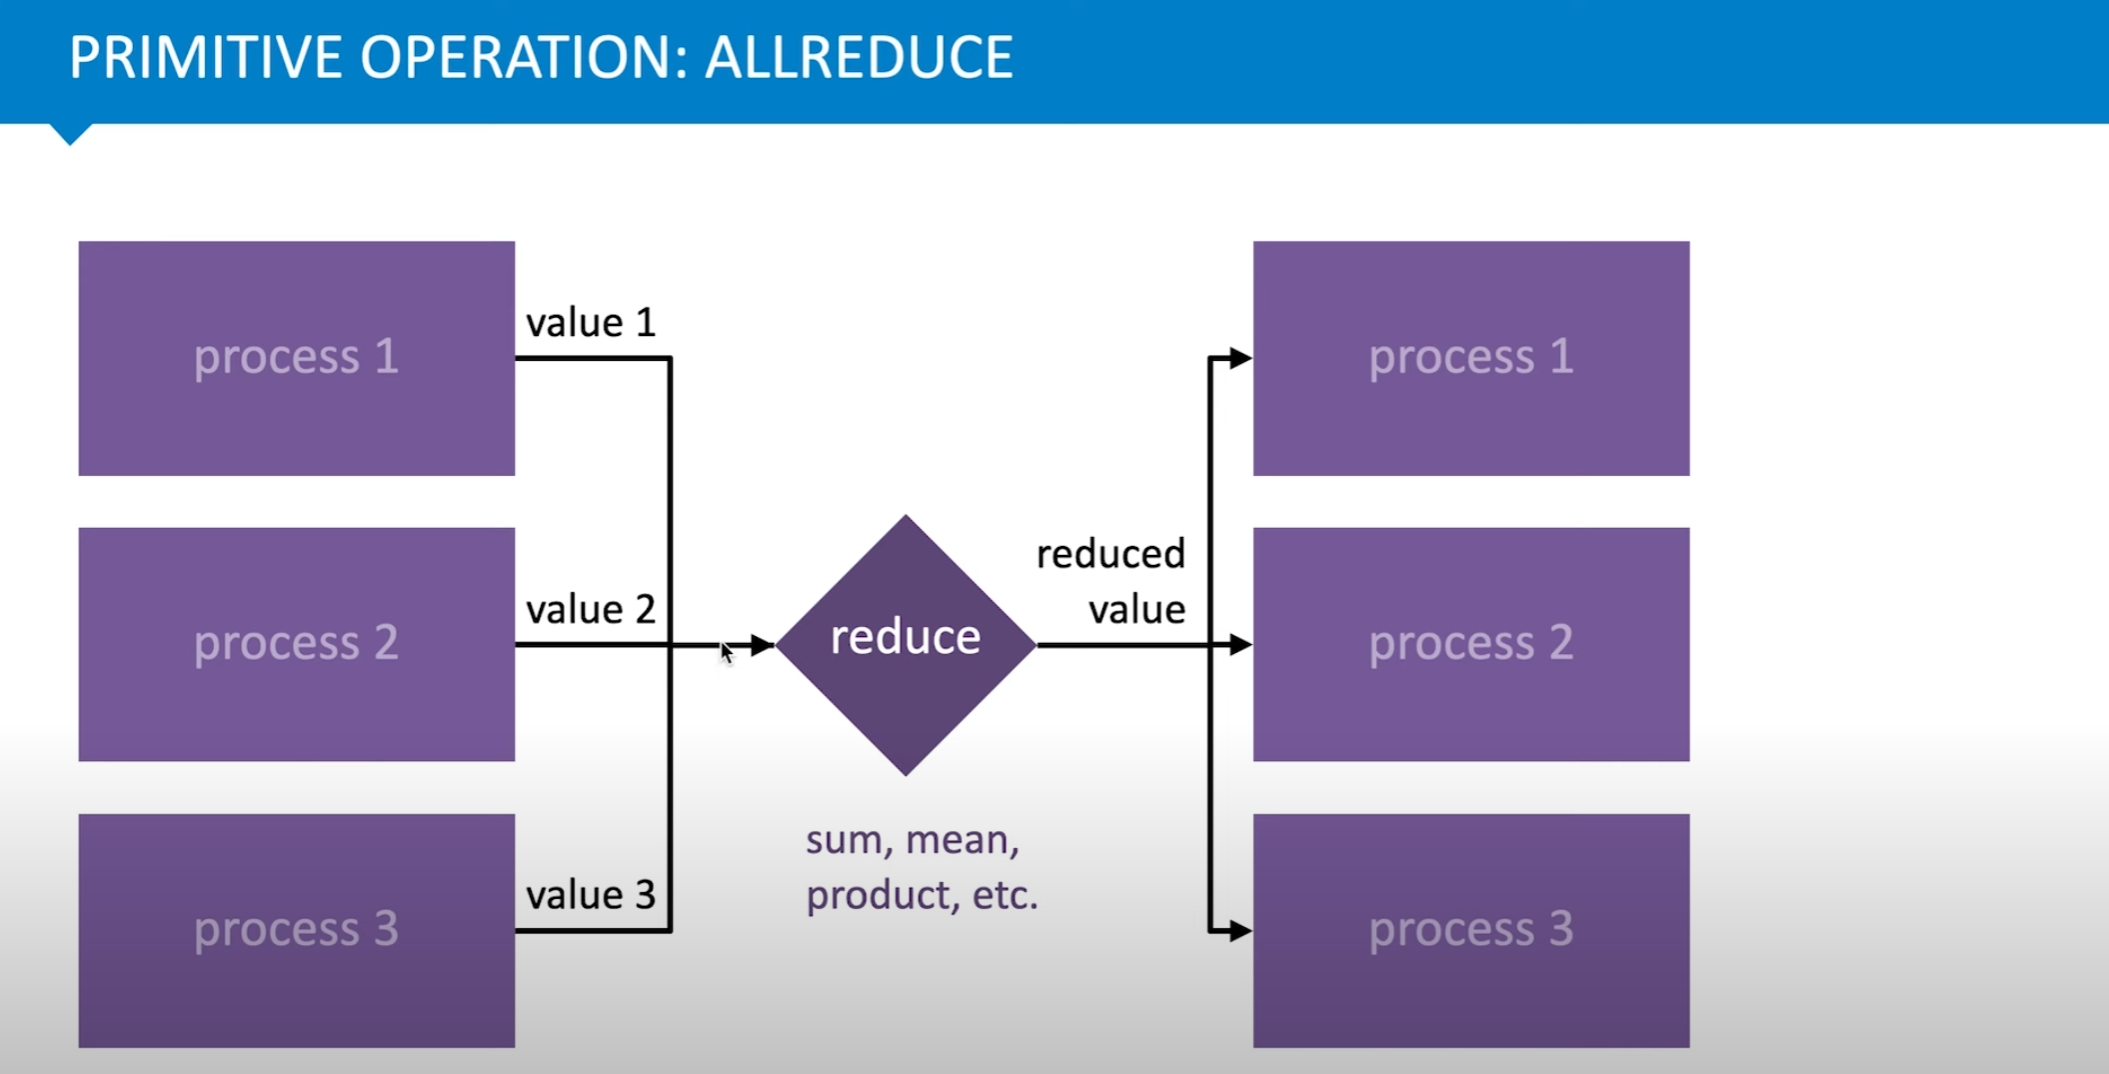

- 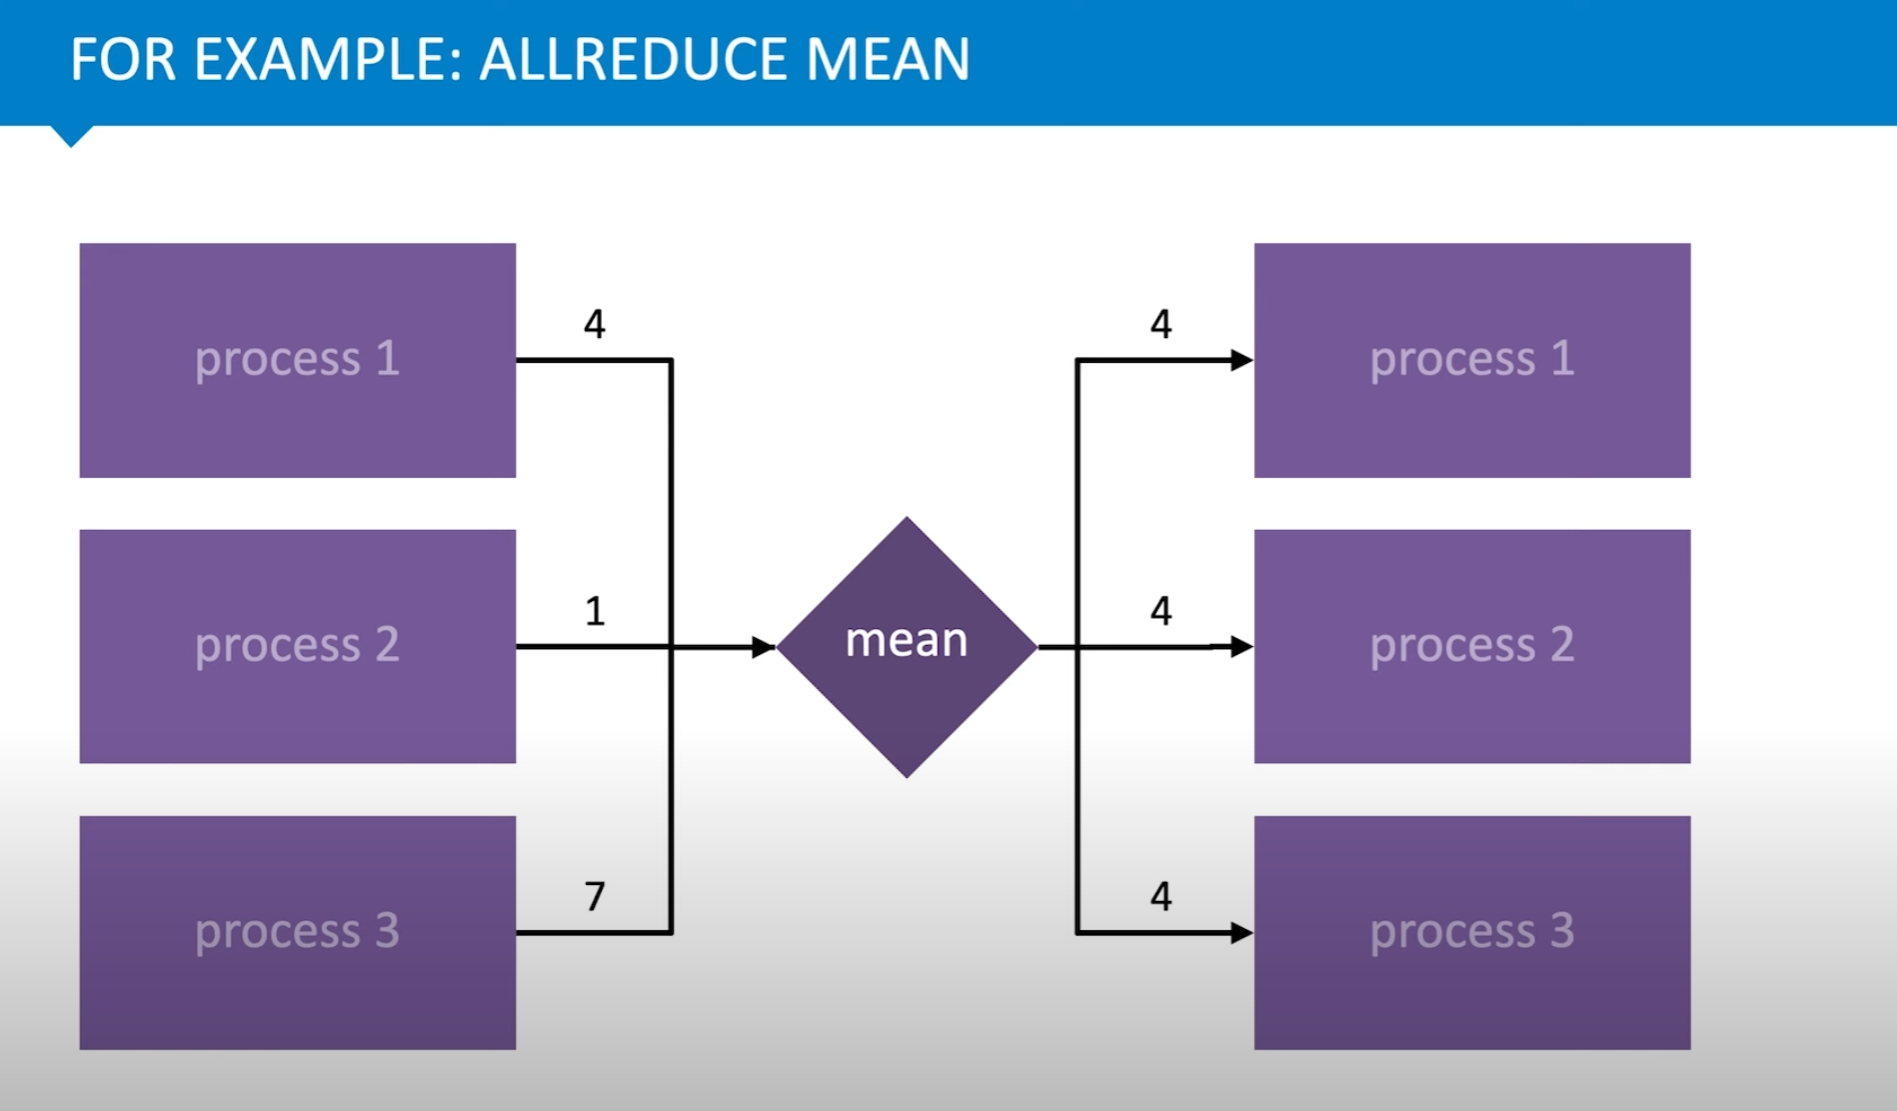


##### AllGather

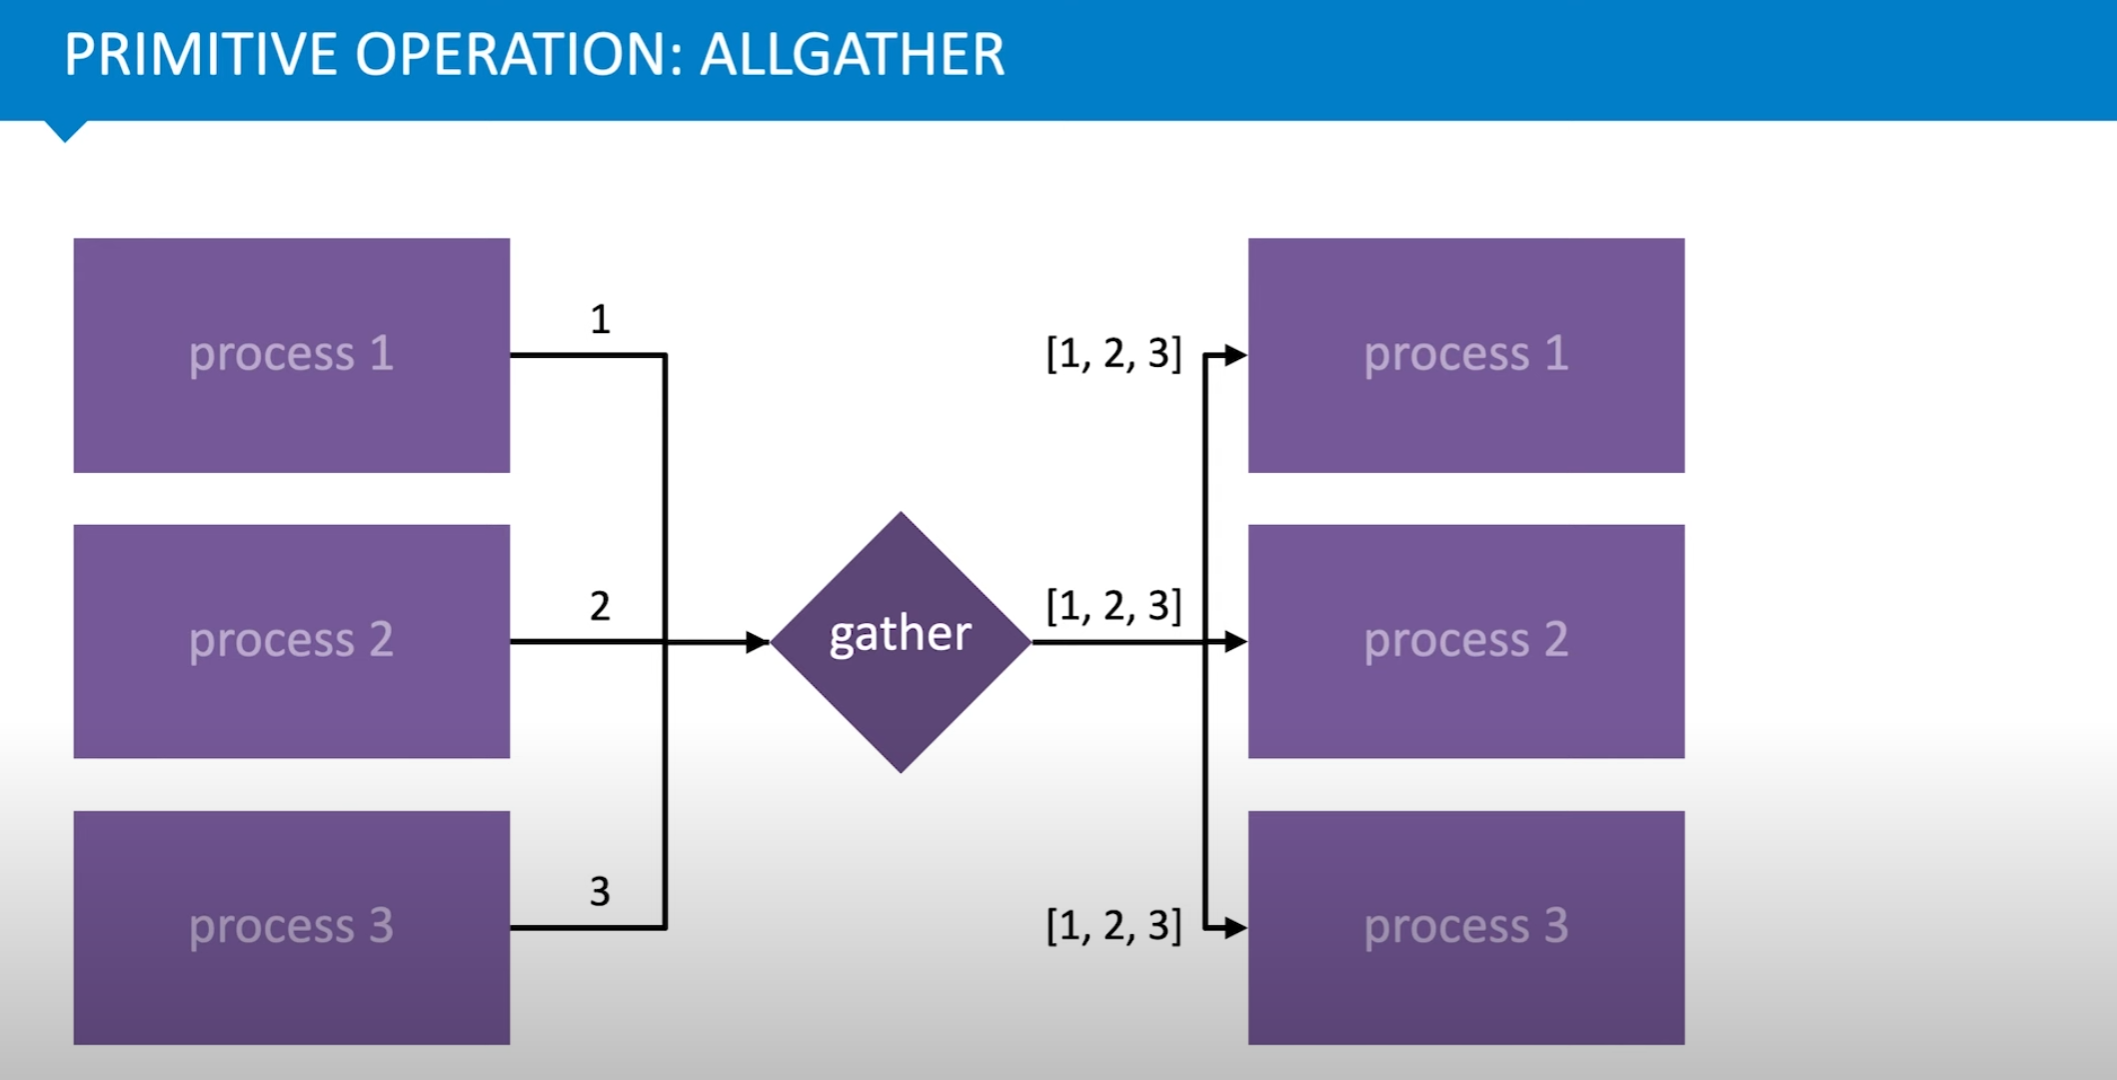



##### Reduce Scatter

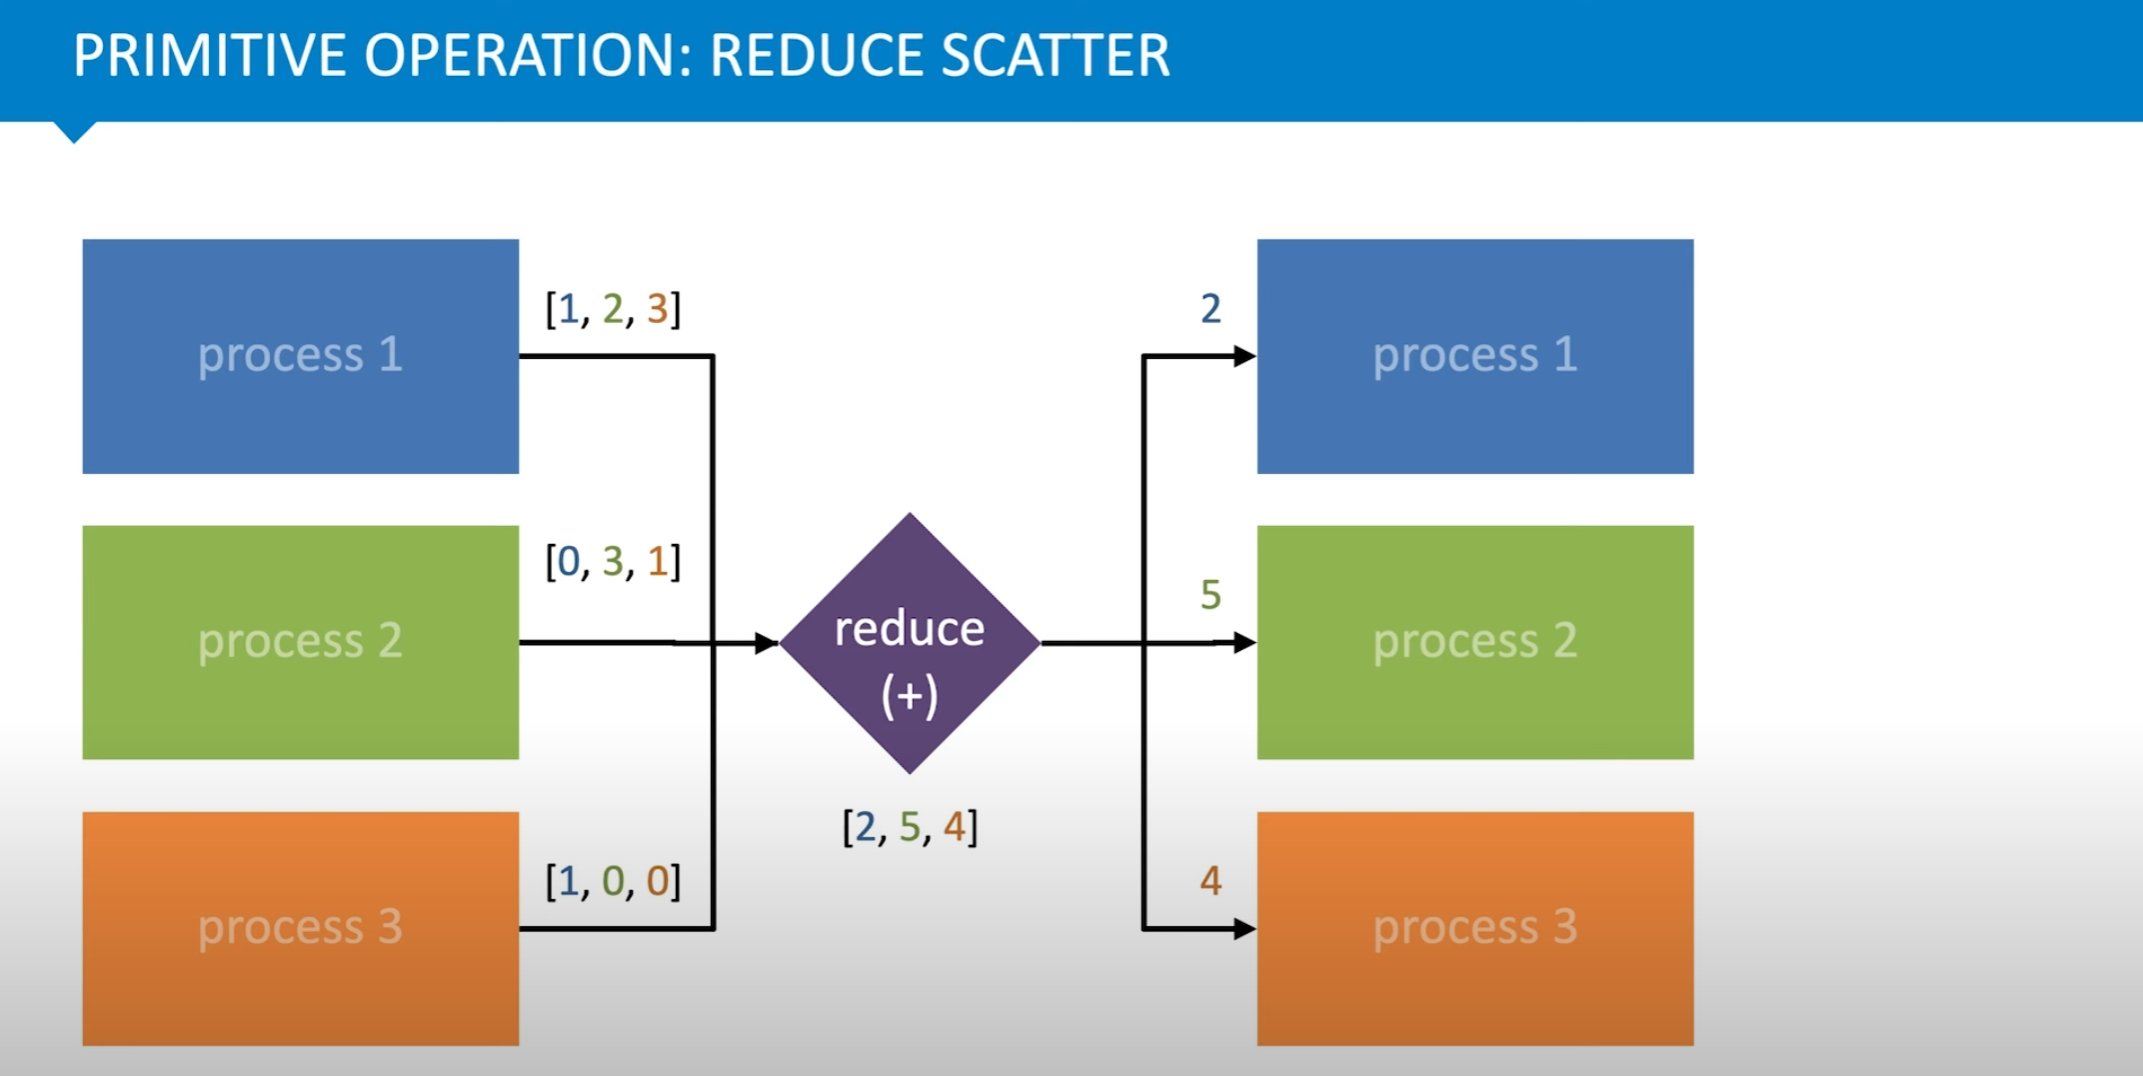

##### Model Parallelism

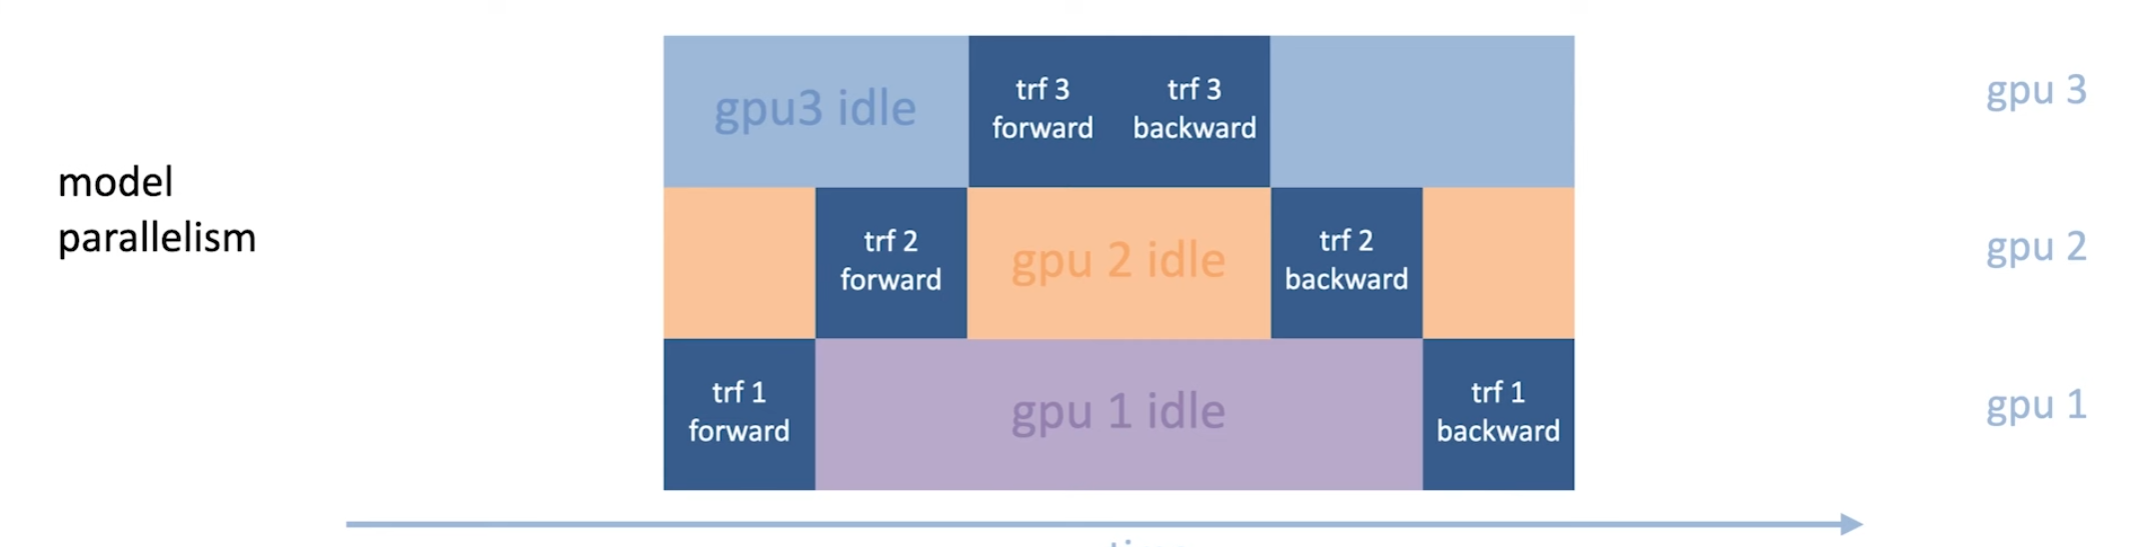

##### Pipeline Parallelism

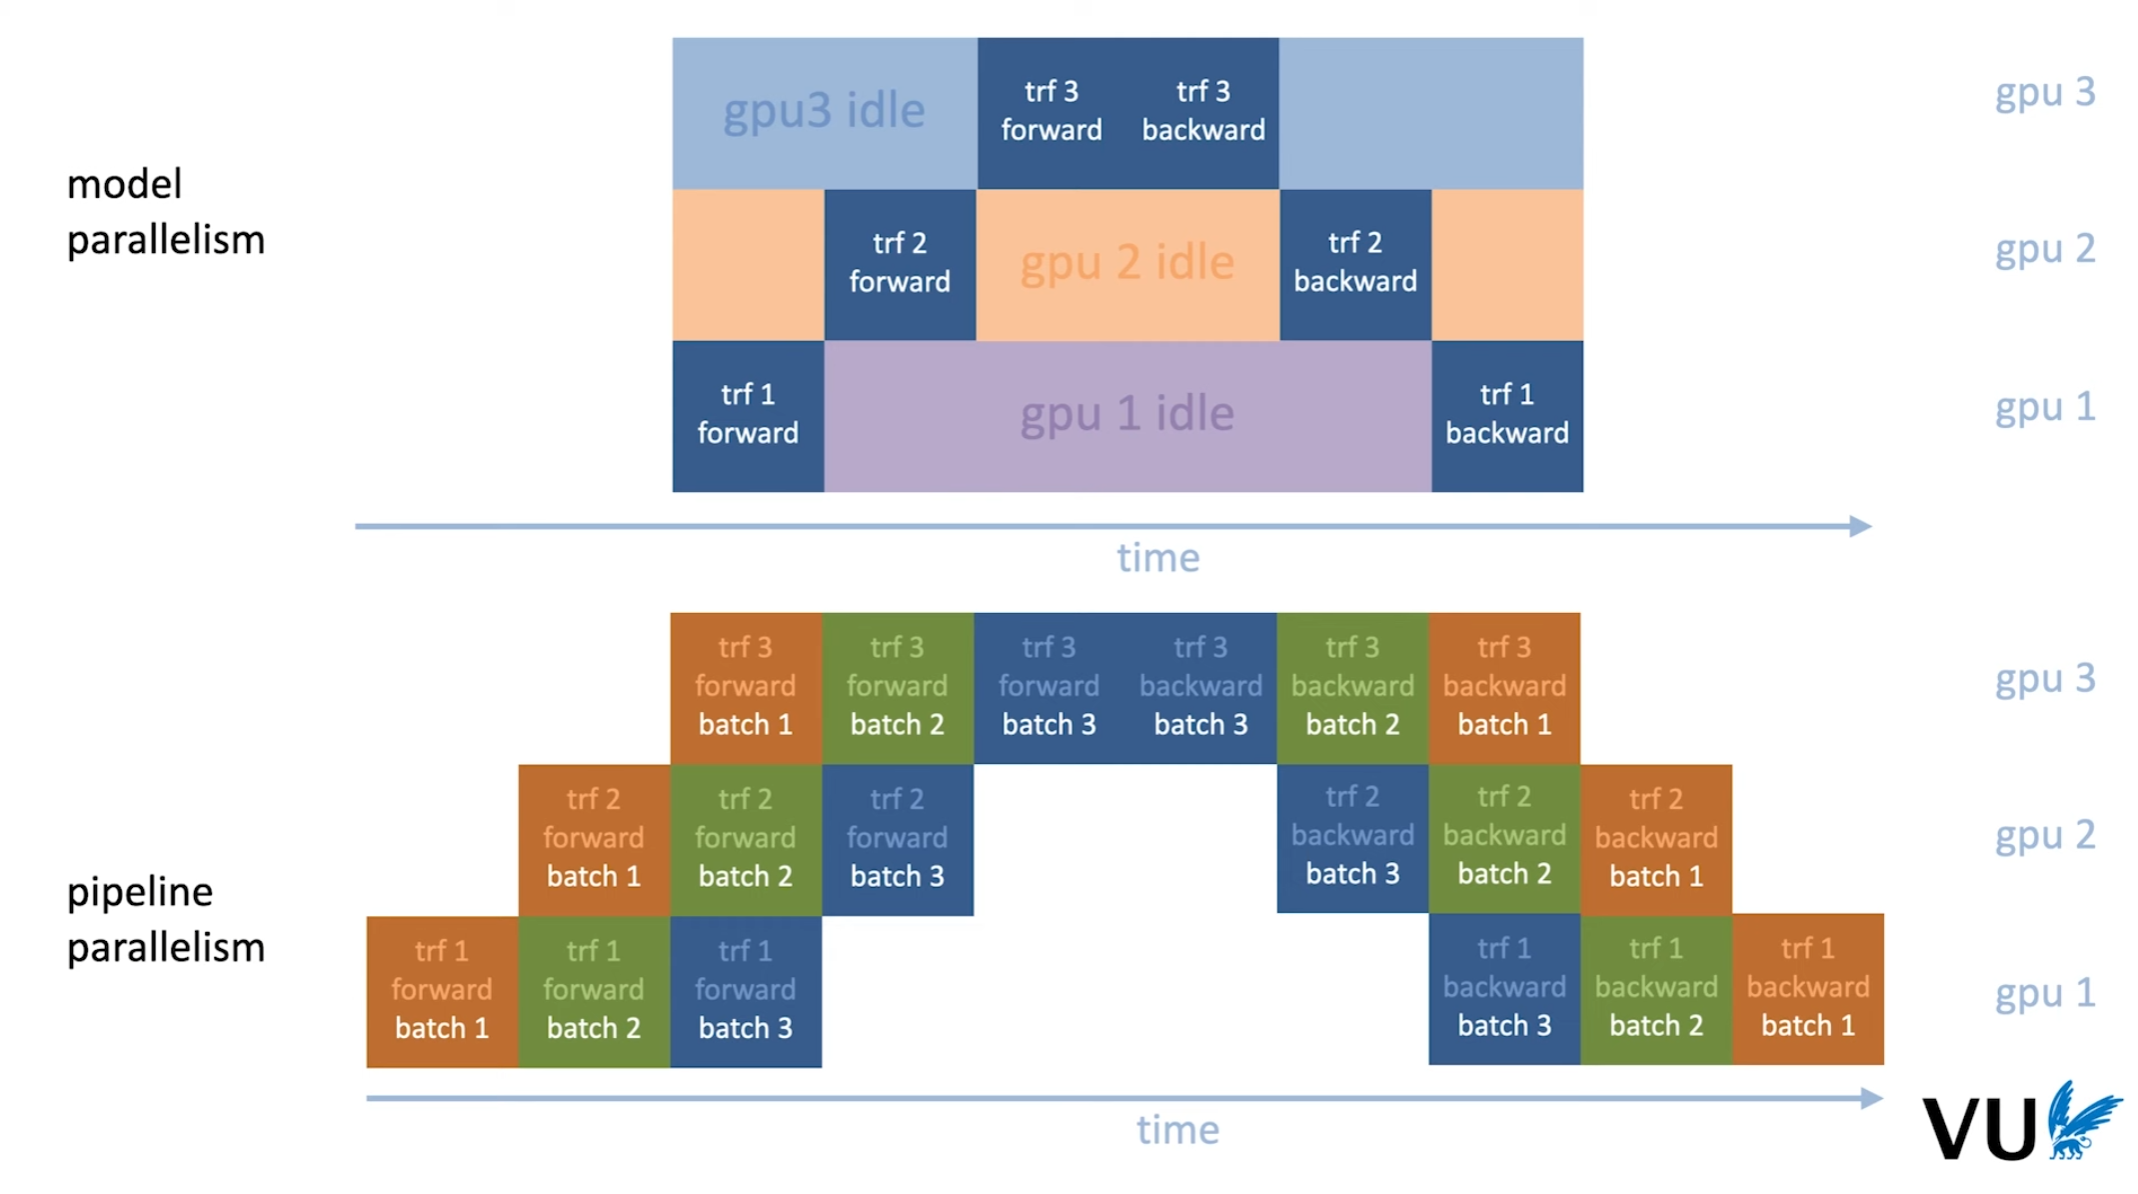

##### Fully Sharded Data Parallel
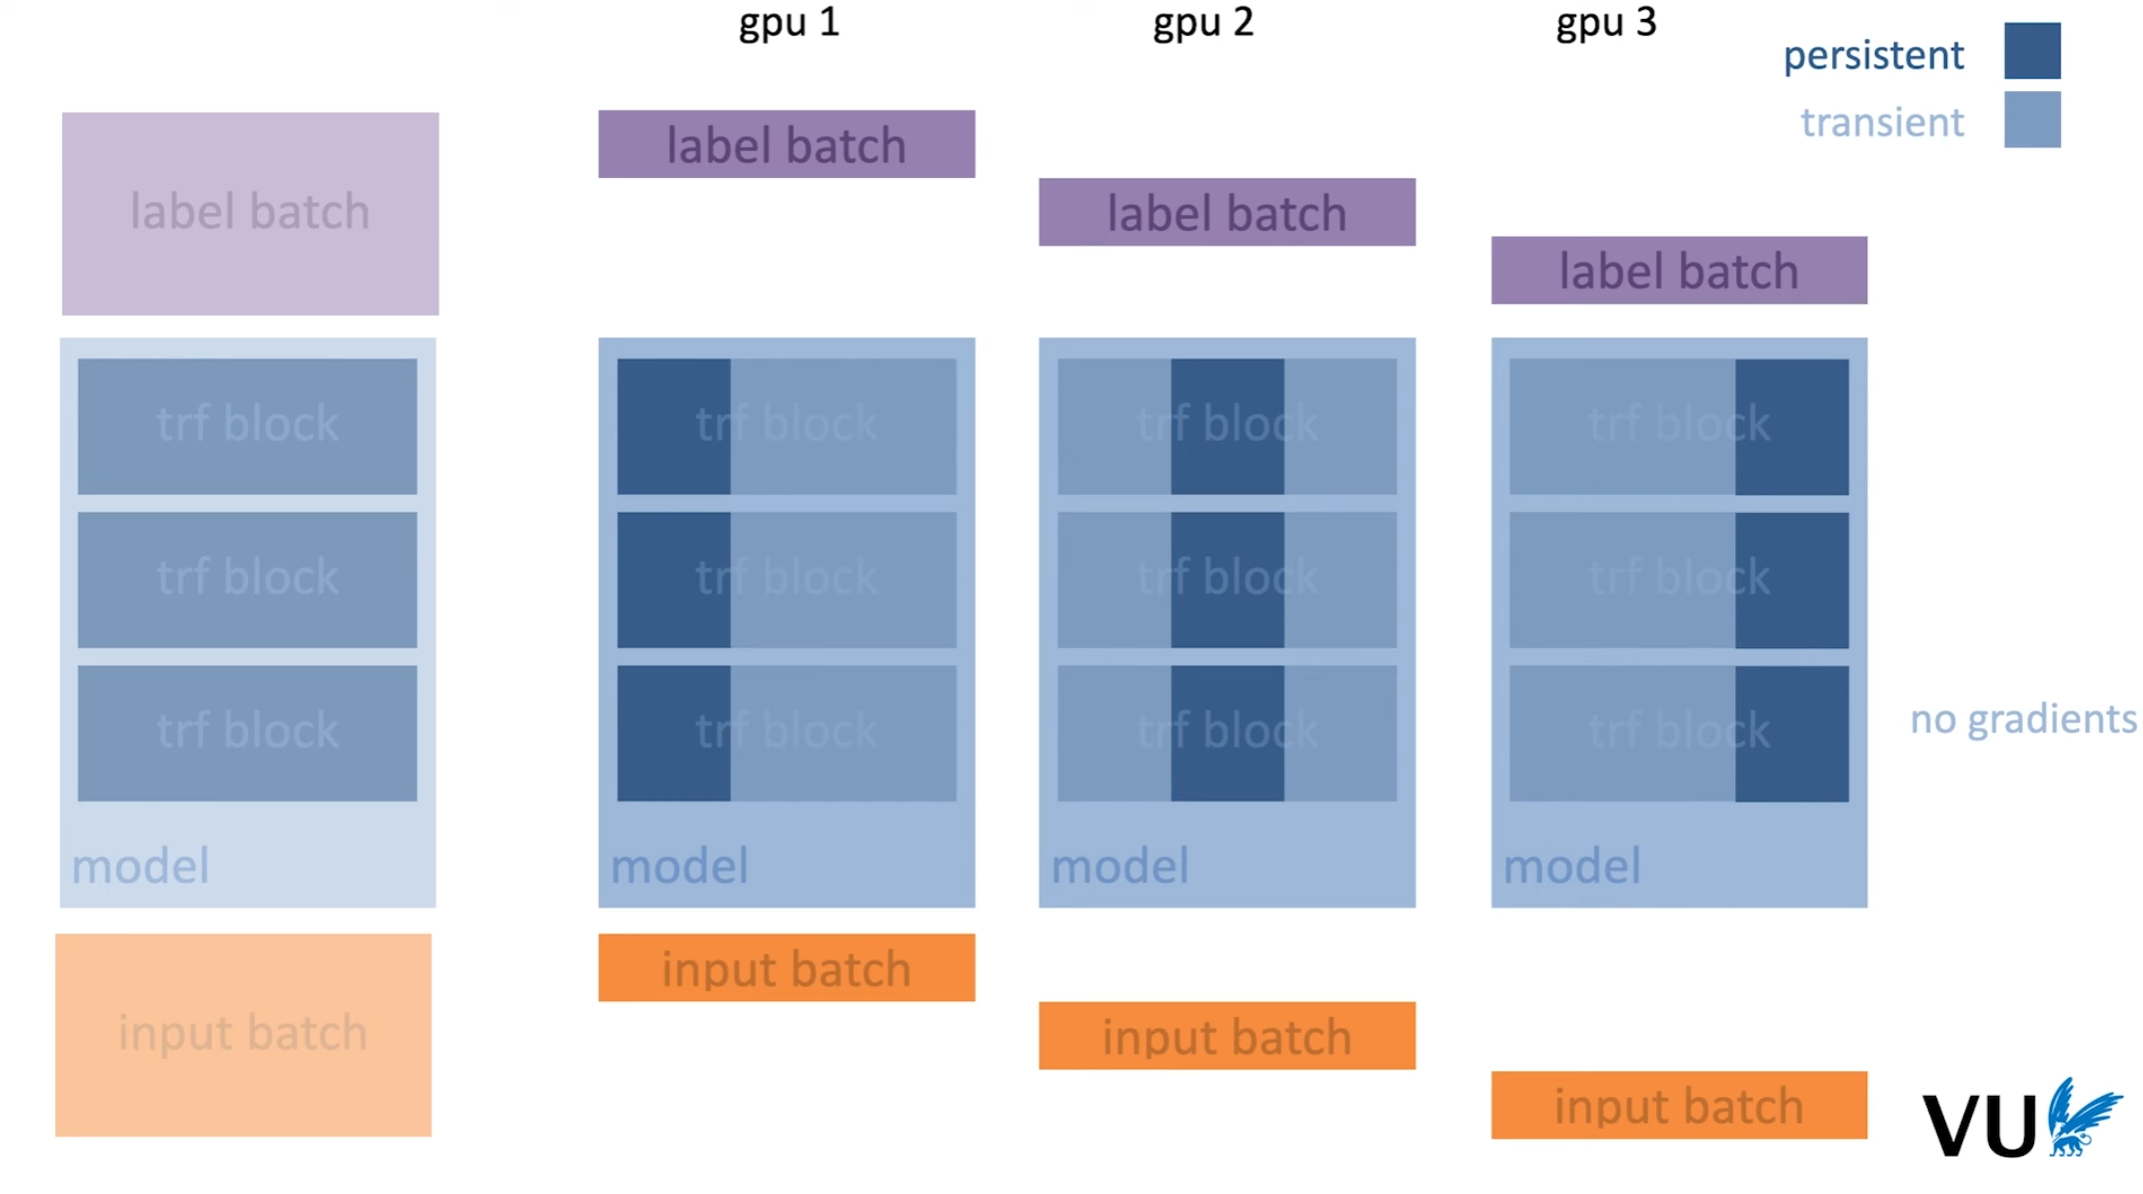

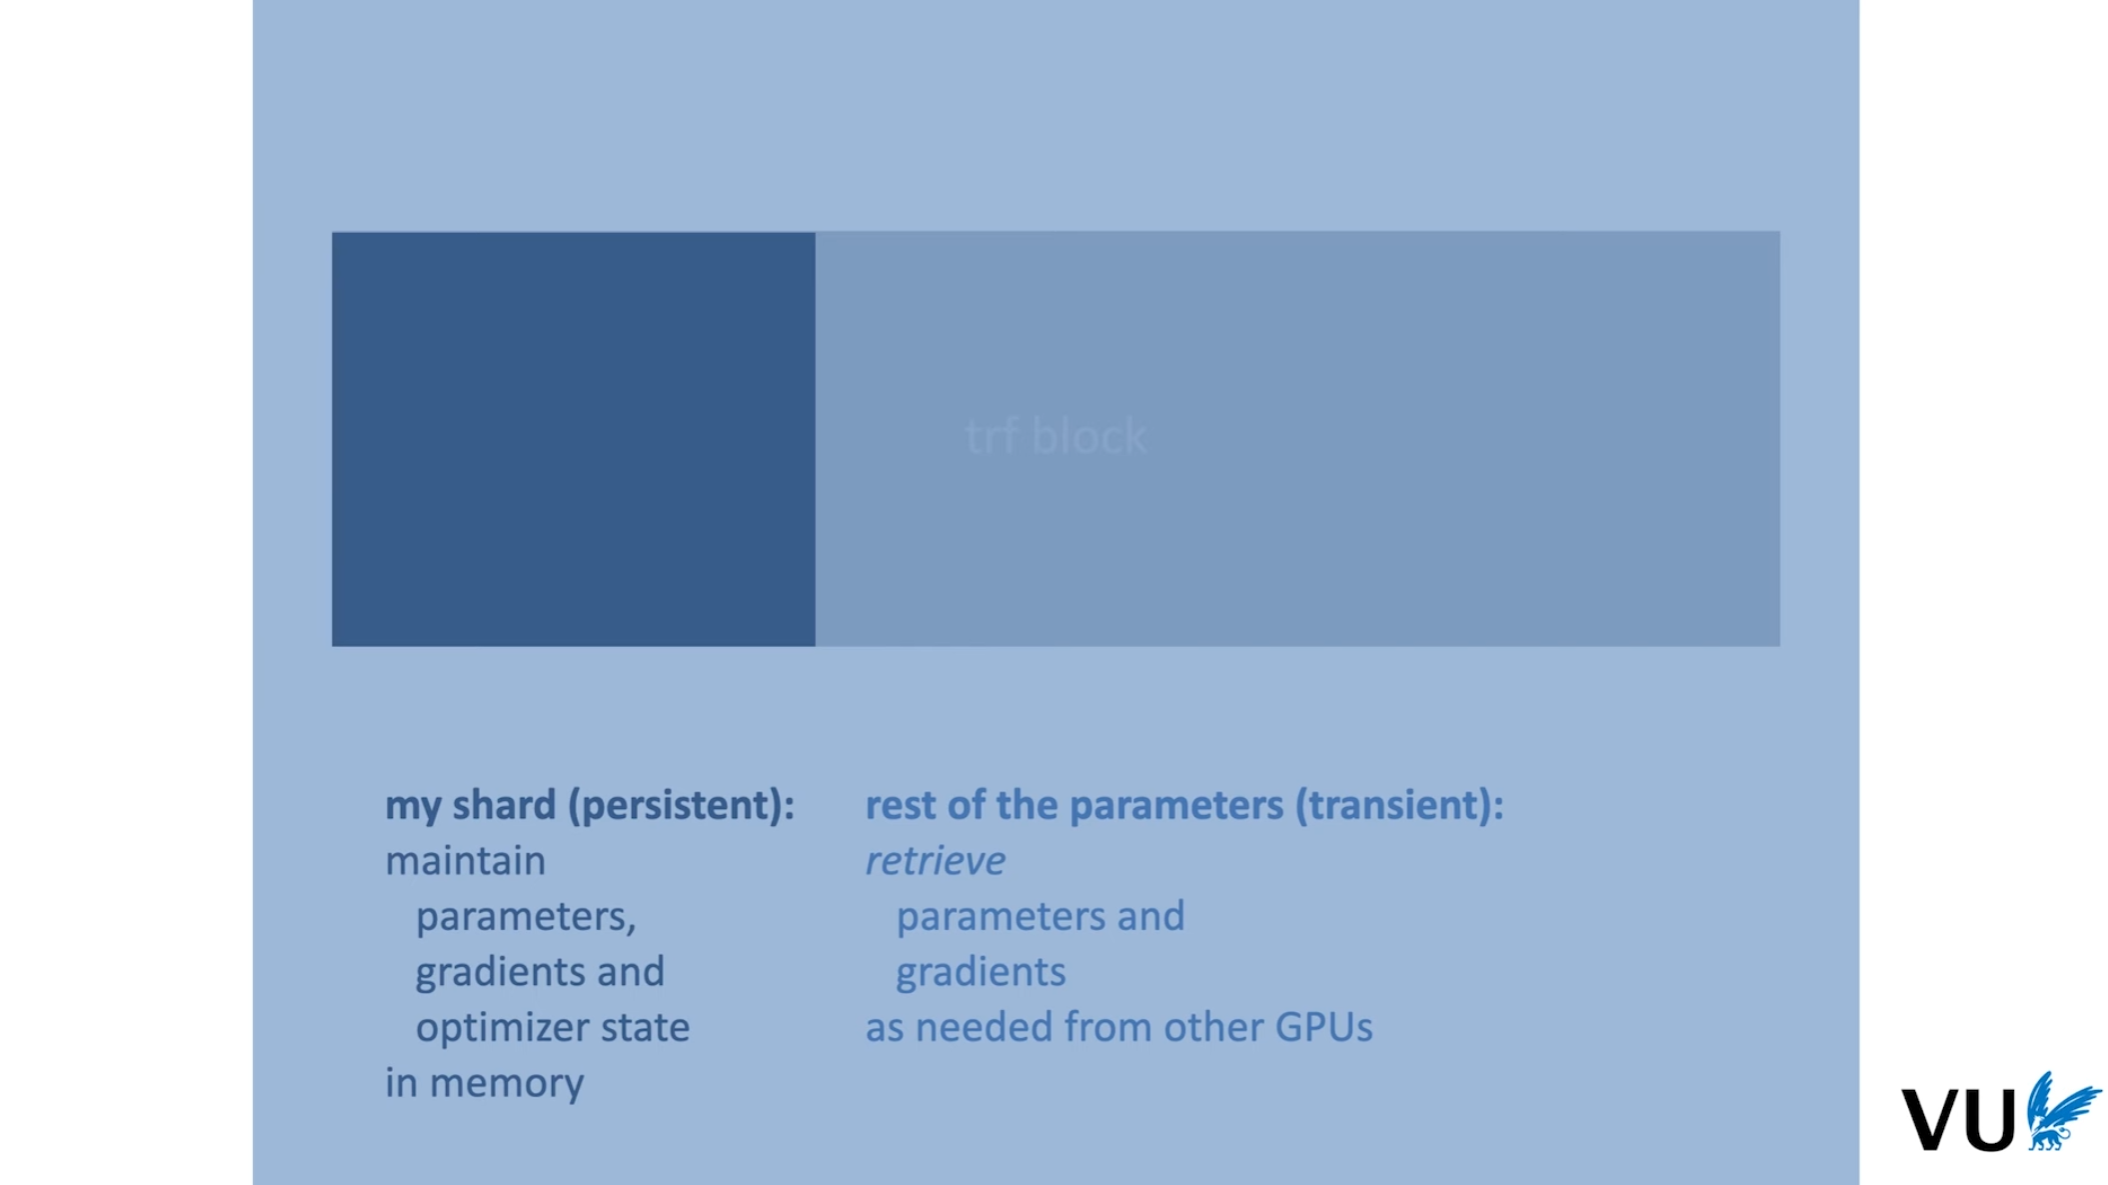

# Github Code

Accelerate SageMaker-PyTorch FSDP Training of Llama-v2 (or GPT-NeoX) with FP8 on P5 instances.
---

This notebook's CI test result for us-west-2 is as follows. CI test results in other regions can be found at the end of the notebook.

![This us-west-2 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/us-west-2/training|distributed_training|pytorch|model_parallel_v2|llama_v2|smp-train-llama-fsdp-tp-fp8.ipynb)

---

In this notebook, you will learn how to accelerate distributed training of the Hugging Face Transformers GPT-NeoX and Llama-v2 models with FP8 mixed precision enabled on P5 instances. We strongly recommend enabling FP8 whenever possible for enhanced training performance.

You can either launch this notebook from an Amazon SageMaker notebook instance which handles all credentials automatically,
or by running it locally and setting credentials manually.

The notebook is accompanied by the following files:
- `train.py`: The entry point script that'll be passed to the SageMaker PyTorch estimator later in this notebook when launching the training job.
- `arguments.py`: This file has functions for argument parsing (i.e. hyperparameters).
- `checkpoints.py`: This file has functions for saving and loading checkpoints.
- `data_utils`: This file has functions for handling S3 URLs.
- `data`: This directory has scripts for preparing and loading data.
- `fsdp_utils.py`: This file has util functions for fully sharded data parallelism.
- `learning_rates.py`: This file has functions for learning rate schedule.
- `logging_utils.py`: This file has functions to handle logging.
- `memory_tracker.py`: This file has functions to track memory usage.
- `requirements.txt`: This file installs the dependencies, including HuggingFace transformers.
- `train_lib.py`: This file has functions for running an end-to-end training of the GPT-NeoX or Llama-v2 model with SMP FSDP, settings for hybrid sharding applied, and implemented with code lines to save, load, and fine-tune the model.
- `train_utils.py`: This file has utility functions for training.

## Additional Resources
- To learn more about launching a multi-node distributed PyTorch training job, see [Launching a Distributed Training Job](https://sagemaker.readthedocs.io/en/stable/frameworks/pytorch/using_pytorch.html#launching-a-distributed-training-job).
- To learn more about using the SageMaker Python SDK with PyTorch, see [Using PyTorch with the SageMaker Python SDK](https://sagemaker.readthedocs.io/en/stable/frameworks/pytorch/using_pytorch.html).
- To learn more about launching a training job in Amazon SageMaker with your own training image, see [Use Your Own Training Algorithms](https://docs.aws.amazon.com/sagemaker/latest/dg/your-algorithms-training-algo.html).

## Prerequisites
You need to create an `S3` bucket to store the input data for training.
This bucket must be located in the same AWS Region that you choose to launch your training job. To learn how to create a `S3` bucket,
see [Create your first S3 bucket](https://docs.aws.amazon.com/AmazonS3/latest/userguide/creating-bucket.html) in the Amazon S3 documentation.

## Launching Environment

### Amazon SageMaker Notebook
You can run the notebook with an Amazon SageMaker notebook instance without manually setting your aws credentials.

1. Create a new SageMaker notebook instance and open it.
2. Zip the contents of this folder & upload to the instance with the `Upload` button on the top-right.
3. Open a new terminal with `New -> Terminal`.
4. Within the terminal, enter the correct directory and unzip the file.
    1. `cd SageMaker && unzip <your-zip-name-here>.zip`

### Locally
You can run locally by launching a Jupyter notebook server with `jupyter notebook`.
This requires you to set your aws credentials in the environment manually.
See [Configure the AWS CLI](https://docs.aws.amazon.com/cli/latest/userguide/cli-chap-configure.html) for more details.

## Amazon SageMaker Initialization
Run the following cell to import SageMaker modules and retrieve information of your current SageMaker work environment,
such as your AWS account ID, the AWS Region, and the ARN of your Amazon SageMaker execution role.
Upgrade SageMaker SDK to the latest version.

**NOTE:** This step might require a kernel restart.

In [ ]:
%pip install --upgrade "sagemaker>=2.224"
%pip install sagemaker-experiments

### AWS Setup

In [ ]:
%%time
import os

import boto3
import sagemaker
from sagemaker import get_execution_role
from sagemaker.pytorch import PyTorch

role = get_execution_role()
print(f"SageMaker Execution Role: {role}")

client = boto3.client("sts")
account = client.get_caller_identity()["Account"] 
print(f"AWS account: `{account}`.")

session = boto3.session.Session()
region = session.region_name
print(f"AWS region: `{region}`.")

sm_boto_client = boto3.client("sagemaker")
sagemaker_session = sagemaker.session.Session(boto_session=session)

# get default bucket
default_bucket = sagemaker_session.default_bucket()

print(f"\nDefault bucket for this session: `{default_bucket}`.")

# FSX setup if you plan to use it.
# - Specify FSx Lustre file system id.
FSX_FILE_SYSTEM_TYPE = "FSxLustre"
FSX_FILE_SYSTEM_ID = "fs-XXXXXXXXXXXXXXXXX"  # Sample: "fs-[a-z0-9]+"

# - Specify the SG and subnet used by the FSX, these are passed to SM Estimator so jobs use this as well.
FSX_SECURITY_GROUP_ID = "sg-XXXXXXXXXXXXXXXXX"  # Sample: "sg-[a-z0-9]+"
FSX_SUBNET_ID = "subnet-XXXXXXXXXXXXXXXXX"  # Sample: "subnet-[a-z0-9]+"

# - Specify directory path for input data on the file system.
# You need to provide normalized and absolute path below.
# Your mount name can be provided by you when creating fsx, or generated automatically.
# You can find this mount_name on the FSX page in console.
# Example of fsx generated mount_name: "3x5lhbmv"
# Example base path: "/3x5lhbmv"
FSX_FILE_SYSTEM_BASE_PATH = "/XXXXXXXX"

## Download and Prepare the Dataset

Here you will download, prepare the dataset and then copy the files to S3.

### Install the Hugging Face Transformers and Datasets libraries

In [ ]:
! pip install -q datasets transformers

In [ ]:
# @title Imports.

import datasets
from datasets import load_dataset, load_from_disk, load_metric
from sagemaker.pytorch import PyTorch
import transformers
import logging

from transformers import AutoTokenizer
from transformers.testing_utils import CaptureLogger

logger = logging.getLogger(__name__)

### Choose Model

Choose to train either the `GPT-NeoX` or `Llama-v2` model.

In [ ]:
# model_type = "llama_v2"  # ["gpt_neox", "llama_v2"]
model_type = "llama-3"

### Load data

This section loads the [GLUE/SST2](https://huggingface.co/datasets/glue/viewer/sst2/train) dataset
and splits it to training and validation datasets.
You can update this section to load any HuggingFace dataset you want.

In [ ]:
# @title Prepare datasets.

# hyperparameters = {
#     "cache_dir": "tmp",
#     "dataset_config_name": "sst2",
#     "dataset_name": "glue",
#     "do_train": True,
#     "do_eval": True,
# }

hyperparameters = {
    "cache_dir": "tmp",
    "dataset_config_name": "sst2",
    "dataset_name": "glue",
    "do_train": True,
    "do_eval": True,
}

raw_datasets = load_dataset(
    hyperparameters["dataset_name"],
    hyperparameters["dataset_config_name"],
)

###  NOTE: Remove existing validation dataset, as it is too small to shard across all ranks.
# del raw_datasets["validation"]

if "validation" not in raw_datasets.keys():
    validation_percentage = "10%"

    raw_datasets["validation"] = load_dataset(
        hyperparameters["dataset_name"],
        hyperparameters["dataset_config_name"],
        split=f"train[:{validation_percentage}]",
        cache_dir=hyperparameters["cache_dir"],
    )

    raw_datasets["train"] = load_dataset(
        hyperparameters["dataset_name"],
        hyperparameters["dataset_config_name"],
        split=f"train[{validation_percentage}:]",
        cache_dir=hyperparameters["cache_dir"],
    )

### Load tokenizer
Nearly every NLP task begins with a tokenizer,
which converts your text data into a format (token) that can be processed by the NLP model.

The following cell loads a tokenizer for GPT-NeoX-7B using [AutoTokenizer.from_pretrained()](https://huggingface.co/docs/transformers/v4.19.4/en/autoclass_tutorial#autotokenizer).

In [ ]:
# @title Tokenizer.

tokenizer_kwargs = {
    "cache_dir": hyperparameters["cache_dir"],
}

tokenizer = AutoTokenizer.from_pretrained("EleutherAI/gpt-neox-20b", **tokenizer_kwargs)

### Preprocess data

Set up a function to run the tokenizer and group texts into chunks smaller than the block size.

In [ ]:
# @title Util functions.


def tokenize_function(examples):
    tok_logger = transformers.utils.logging.get_logger("transformers.tokenization_utils_base")

    with CaptureLogger(tok_logger) as cl:
        output = tokenizer(examples[text_column_name])
        # clm input could be much much longer than block_size
        if "Token indices sequence length is longer than the" in cl.out:
            tok_logger.warning(
                "^^^^^^^^^^^^^^^^ Please ignore the warning above - this long input will be chunked into smaller bits before being passed to the model."
            )
    return output


# Main data processing function that will concatenate all texts from our dataset and generate chunks of block_size.
def group_texts(examples):
    # Concatenate all texts.
    concatenated_examples = {k: sum(examples[k], []) for k in examples.keys()}
    total_length = len(concatenated_examples[list(examples.keys())[0]])
    # We drop the small remainder, we could add padding if the model supported it instead of this drop, you can
    # customize this part to your needs.
    if total_length >= block_size:
        total_length = (total_length // block_size) * block_size
        # Split by chunks of max_len.
        result = {
            k: [t[i : i + block_size] for i in range(0, total_length, block_size)]
            for k, t in concatenated_examples.items()
        }
    result["labels"] = result["input_ids"].copy()
    return result

In [ ]:
# @title Tokenize datasets.

column_names = raw_datasets["train"].column_names
text_column_name = "text" if "text" in column_names else column_names[0]

# since this will be pickled to avoid _LazyModule error in Hasher force logger loading before tokenize_function
tok_logger = transformers.utils.logging.get_logger("transformers.tokenization_utils_base")

tokenized_datasets = raw_datasets.map(
    tokenize_function,
    batched=True,
    num_proc=1,
    remove_columns=column_names,
    desc="Running tokenizer on dataset",
)


block_size = tokenizer.model_max_length
if block_size > 2048:
    logger.warning(
        f"The tokenizer picked seems to have a very large `model_max_length` ({tokenizer.model_max_length}). "
        "Picking 2048 instead. You can change that default value by passing --block_size xxx."
    )
    block_size = 2048
else:
    if args.block_size > tokenizer.model_max_length:
        logger.warning(
            f"The block_size passed ({block_size}) is larger than the maximum length for the model"
            f"({tokenizer.model_max_length}). Using block_size={tokenizer.model_max_length}."
        )
    block_size = min(block_size, tokenizer.model_max_length)

lm_datasets = tokenized_datasets.map(
    group_texts,
    batched=True,
    #     num_proc=args.preprocessing_num_workers,
    desc=f"Grouping texts in chunks of {block_size}",
)

Set additional hyperparameters and S3 paths for mapping the train and validation datasets properly depending on the phase (training or validation) of the training job in each epoch.

In [ ]:
# @title Prepare datasets.

if hyperparameters["do_train"]:
    train_dataset = lm_datasets["train"]
    train_dataset.to_json("./training.json")
    training_dataset_location = f"s3://{default_bucket}/dataset/train/"

    command = f"aws s3 cp ./training.json {training_dataset_location}"
    os.system(command)
else:
    training_dataset_location = None

if hyperparameters["do_eval"]:
    eval_dataset = lm_datasets["validation"]
    eval_dataset.to_json("./validation.json")
    validation_dataset_location = f"s3://{default_bucket}/dataset/validation/"

    command = f"aws s3 cp ./validation.json {validation_dataset_location}"
    os.system(command)
else:
    validation_dataset_location = None


if hyperparameters["do_train"]:
    command = "rm ./training.json"
    os.system(command)

if hyperparameters["do_eval"]:
    command = "rm ./validation.json"
    os.system(command)

In [ ]:
%store training_dataset_location
%store validation_dataset_location

%store

## Specify Amazon S3 Bucket Paths
Here you need to specify the paths for training data to be used by your job. The bucket used must be in the same region as where training will run. In the cells above you downloaded the GLUE/SST2 training and validation split datasets and uploaded the json files in an S3 bucket in your account. This example will train on those json files.

After you successfully run this example tensor parallel + fully sharded data parallel training job, you can modify the S3 bucket to where your own dataset is stored.

In [ ]:
%store -r training_dataset_location
%store -r validation_dataset_location

# if you're bringing your own data, uncomment the following lines and specify the locations there
# training_dataset_location = YOUR_S3_BUCKET/training
# validation_dataset_location = YOUR_S3_BUCKET/validation

In [ ]:
s3_train_bucket = training_dataset_location
s3_test_bucket = validation_dataset_location

The following S3 bucket will store the output artifacts of the training job. You can modify this as needed.

In [ ]:
s3_output_bucket = f"s3://sagemaker-{region}-{account}/smp-fsdp-tp/{model_type}-outputdir/"

## Define Data Channels for SageMaker Training Using Amazon S3
In this step, define SageMaker training data channels to the S3 buckets.



In [ ]:
# @title Setup if you do not use fsx.

use_fsx = False

if not use_fsx:
    if s3_train_bucket != None:
        train = sagemaker.inputs.TrainingInput(
            s3_train_bucket, distribution="FullyReplicated", s3_data_type="S3Prefix"
        )
        data_channels = {"train": train}
    else:
        data_channels = {"train": mock_data}
    if s3_test_bucket != None:
        test = sagemaker.inputs.TrainingInput(
            s3_test_bucket, distribution="FullyReplicated", s3_data_type="S3Prefix"
        )
        data_channels["test"] = test
    else:
        data_channels["test"] = mock_data
    print(data_channels)

### (Optional) Set Up and Use Amazon FSx for Data Channels and Checkpoints
While the previous option of using Amazon S3 is easier to setup, using an FSx can be beneficial for performance when dealing with large input sizes and large model sizes and is more stable. In general, checkpointing should be done using FSx.

Please see the instructions from [Distributed Training of Mask-RCNN in Amazon SageMaker Using FSx](https://github.com/aws/amazon-sagemaker-examples/blob/main/advanced_functionality/distributed_tensorflow_mask_rcnn/mask-rcnn-scriptmode-fsx.ipynb) to create an FSx Lustre file system and import the dataset from the S3 bucket to your FSx file system. Note that the FSx file system must be created in a private subnet with internet gateway to ensure that training job has access to the internet. For general guidance on setting an FSx Lustre file system as data input channel, see Configure Data Input Channel to Use Amazon FSx for Lustre.

In [ ]:
# @title Setup FSX as needed.

# Instructions obtained from:
# https://github.com/aws/amazon-sagemaker-examples/blob/main/advanced_functionality/distributed_tensorflow_mask_rcnn/mask-rcnn-scriptmode-fsx.ipynb

if use_fsx:
    from sagemaker.inputs import FileSystemInput

    train = FileSystemInput(
        directory_path=FSX_FILE_SYSTEM_BASE_PATH,
        file_system_access_mode="rw",
        file_system_id=FSX_FILE_SYSTEM_ID,
        file_system_type=FSX_FILE_SYSTEM_TYPE,
    )

    data_channels = {"train": train, "test": train}

## Set Hyperparameters, Metric Definitions, and MPI Options

### FP8 Datatype

FP8 (an 8-bit floating point precision) is a datatype suitable for mixed precision training, a natural progression for accelerating deep learning training beyond the 16-bit formats such as FP16 and BF16. NVIDIA H100 GPUs came out supporting mixed precision training with FP8 data types. With P5 instances equipped with H100 GPUs, you can accelerate distributed training with FP8 mixed precision.

For more information, see [FP8 training on P5](https://docs.aws.amazon.com/sagemaker/latest/dg/model-parallel-core-features-v2-fp8-training-on-p5.html).


In [ ]:
tensor_parallel_degree = 2  # Enables tensor parallelism with a degree of 2.,  An integer in [1, world_size]. Note: we recommend using TP_DEGREE in [1,8] for intra-node communication as inter-node TP communication is slow.

hybrid_shard_degree = ( # SMPv2 only , the SMP library overrides the strategy in the script and sets it to ShardingStrategy.HYBRID_SHARD if hybrid_shard_degree > 2 
                       # Enables hybrid sharding with a degree of 4, which includes FSDP. 
                        4  # An integer in [0, world_size // tensor_parallel_degree] and its default value is 0.
                       # # HYBRID_SHARD: Apply FULL_SHARD within a node, and replicate parameters across nodes.
)

offload_activations = True  # Enables SM activation offloading implementation. # a technique used to reduce memory usage by offloading activations (intermediate outputs of layers) to CPU memory or other storage during the forward pass and loading them back during the backward pass.

activation_loading_horizon = ( # how many layers ahead the activations should be pre-loaded into GPU memory during the backward pass.
    2  # Activation loading horizon, a positive integer and its default value is 2.
)

save_steps = 50  # Save step interval.
max_steps = 50  # Maximum training steps.

hyperparameters = {
    "train_batch_size": 2,  # batch size per dp rank, for tensor parallelism degree 8 with pipeline parallel degree 1 this means 8*this batch size per node
    "val_batch_size": 4,
    "fast_validation": 0,   # Running validation only with the last data file for faster speed
    "max_steps": max_steps,
    "epochs": 100,
    "seed": 12345,
    "bf16": 1,      # automatic mixed precision training
    "lr": 0.0001,
    "min_lr": 1e-05,
    "beta1": 0.9,
    "beta2": 0.95,
    "lr_decay_style": "cosine",
    "lr_decay_iters": 47683,
    "warmup": 0.0032,
    "plateau": 0.0,
    "delayed_param": 1,
    "num_kept_checkpoints": 2,
    "checkpoint_freq": save_steps,
    "checkpoint_dir": "/opt/ml/checkpoints",
    "validation_freq": save_steps,
    "logging_freq": 1,
    "weight_decay": 0.2,
    "clean_cache": 0,       # Clean torch reserved memory at he end of every step
    "activation_checkpointing": 1,
    "enable_memory_profiling": 0,
    "forward_prefetch": 1,  # Loading data or inputs ahead of time, before they are needed for computation
    
    # "vocab_size": 50257,
    "vocab_size": 128256,    
    
    "limit_all_gathers": 1, # the system can control the frequency and scope of all-gather operations.
    "backward_fetch_policy": "backward_pre",
    "sharding_strategy": "hybrid_shard",        # Hybrid sharding is a mix of Tensor parallelism, pipeline parallelism and FSDP 
    "auto_wrap_policy": "transformer_auto_wrap_policy",
    "model_type": model_type,
    "use_smp_flash_attn": 1,
    "use_smp_implementation": 1,
    "distributed_backend": "nccl",
}

if use_fsx:
    # make sure to update paths for training_dir and test_dir based on the paths of datasets in fsx
    # If you want to resume training, set checkpoint_dir to the same path as a previous job.
    SM_TRAIN_DIR = "/opt/ml/input/data/train"
    hyperparameters["checkpoint_dir"] = f"{SM_TRAIN_DIR}/smp-v2/{model_type}/checkpointdir"
    hyperparameters["training_dir"] = f"{SM_TRAIN_DIR}/datasets/c4/en/hf-tokenized/llama/train"
    hyperparameters["test_dir"] = f"{SM_TRAIN_DIR}/datasets/c4/en/hf-tokenized/llama/val"
    hyperparameters["zipped_data"] = 1
    hyperparameters["dataset_type"] = "hf"
else:
    hyperparameters["zipped_data"] = 0
    hyperparameters["dataset_type"] = "gpt_jsonl"

# The checkpoint path (hyperparameters['checkpoint_dir'] or checkpoint_s3_uri) is not unique per job.
# You need to modify as needed for different runs.
# If same path is used for unrelated runs, this may increase time when downloading unnecessary checkpoints,
# and cause conflicts when loading checkpoints.

metric_definitions = [
    {"Name": "base_metric", "Regex": "<><><><><><>"}
]  # Add your custom metric definitions

In [ ]:
# @title Specify model config based on model name and model size.

model_size = 7  # 7B or 65B parameters.

model_configs = {
        "llama-3": {
        8: {
            "hidden_width": 5325,
            "max_context_width": 8192,
            "num_heads": 32,
            "num_layers": 32,
        },
    },
    "gpt_neox": {
        7: {
            "hidden_width": 4096,
            "max_context_width": 2048,
            "num_heads": 32,
            "num_layers": 32,
        },
        65: {
            "hidden_width": 8192,
            "max_context_width": 2048,
            "num_heads": 64,
            "num_layers": 80,
        },
    },
    "llama_v2": {
        7: {
            "hidden_width": 4096,
            "llama_intermediate_size": 11008,
            "max_context_width": 2048,
            "num_heads": 32,
            "num_layers": 32,
        },
        65: {
            "hidden_width": 8192,
            "llama_intermediate_size": 22016,
            "max_context_width": 2048,
            "num_heads": 64,
            "num_layers": 80,
        },
    },
}

model_params = model_configs.get(model_type, {}).get(model_size)
if model_params is None:
    raise RuntimeError(
        f"Unknown model config from (name, size) = ({model_type}, {model_size:02d}B)."
    )

hyperparameters.update(model_params)

## Specify Essential Parameters for a SageMaker Training Job

Next, you use the `SageMaker Estimator class` to define a SageMaker Training Job,
passing values through the following parameters for training job name,
the number of EC2 instances, the instance type,
and the size of the volume attached to the instances.

- `instance_count`
- `instance_type`
- `volume_size`
- `base_job_name`

### Update the Type and Number of EC2 Instance to Use

The instance type and the number of instances you specify to the `instance_type` and `instance_count` parameters,
respectively, determine the total number of GPUs (`world_size`).

$$\text{world_size = (the number of GPUs on a single instance)} \times \text{(the number of instances)}$$

In [ ]:
# @title Setup instances: type and count.

instance_type = "ml.p5.48xlarge"

# You need >= 1 p5 for 7b model.
# You need >= 8 p5 for 65b model.
instance_count = 1

# Set to the number of GPUs on that instance.
processes_per_host = 8

### Specify a Base Job Name

In [ ]:
# @title Job name.

instance_type_str = instance_type.split(".")[1] + instance_type.split(".")[2][:3]

base_job_name = f'smp-{model_size:02d}b-{instance_type_str}-fp8-{fp8}-hs{hybrid_shard_degree}-tp{tensor_parallel_degree}-ao{offload_activations}-bs{hyperparameters["train_batch_size"]:02d}'

print(f"Base job name: `{base_job_name}`.")

In [ ]:
if not use_fsx:
    # If you want to resume training, set checkpoint_s3_uri to the same path as a previous job.
    # Previous checkpoint to load must have same model config.
    checkpoint_bucket = f"s3://sagemaker-{region}-{account}/"
    checkpoint_s3_uri = (
        f"{checkpoint_bucket}/experiments/smp-fsdp-tp-{model_type}-checkpoints/{base_job_name}/"
    )

In [ ]:
# @title Estimator.

if use_fsx:
    # Use the security group and subnet that was used to create the fsx filesystem.
    kwargs = {
        "security_group_ids": [FSX_SECURITY_GROUP_ID],
        "subnets": [FSX_SUBNET_ID],
    }
    print(kwargs)
else:
    kwargs = {}

smp_estimator = PyTorch( # creating an instance of a PyTorch estimator for AWS SageMaker. This estimator is configured to run a distributed training job using SageMaker's Model Parallelism (SMP) library.
    entry_point="train.py", # This script will be executed on each instance in the distributed training job
    hyperparameters=hyperparameters,
    source_dir=os.path.join(os.getcwd(), "../shared-scripts"), # the directory containing the training script and any other necessary files.
    role=role, # the AWS IAM role that SageMaker will use to access resources such as S3 buckets and other AWS services.
    checkpoint_s3_uri=checkpoint_s3_uri if not use_fsx else None, # the S3 URI where checkpoints will be stored if use_fsx is False
    checkpoint_local_path=hyperparameters["checkpoint_dir"] if use_fsx else None, # local path where checkpoints will be stored if use_fsx is True
    instance_type=instance_type,
    volume_size=400, # the size of the EBS volume to attach to each instance.
    instance_count=instance_count,
    sagemaker_session=sagemaker_session,
    distribution={
        "torch_distributed": {
            "enabled": True, # Enables PyTorch's distributed training capabilities.
        },
        "smdistributed": {
            "modelparallel": {
                "enabled": True,
                "parameters": {
                    "tensor_parallel_degree": tensor_parallel_degree,   # Specifies the degree of tensor parallelism.
                    "hybrid_shard_degree": hybrid_shard_degree,         # Specifies the degree of hybrid sharding.
                    "sm_activation_offloading": offload_activations,    # Enables activation offloading to reduce memory usage.
                    "activation_loading_horizon": activation_loading_horizon, # Specifies the activation loading horizon for activation offloading.

                },
            }
        },
    },
    py_version="py311",
    framework_version="2.3.1",
    # image_uri=$IMAGE,  # Either provide `framework_version` or `image_uri`
    output_path=s3_output_bucket,
    max_run=86400,
    debugger_hook_config=False,
    base_job_name=base_job_name,
    metric_definitions=metric_definitions,
    **kwargs,
)

### Start Training

Finally, run the `estimator.fit` method to launch the SageMaker training job of the model with hybrid sharding and activation offloading.

In [ ]:
# @title Start training.

smp_estimator.fit(inputs=data_channels)

## Resume from Checkpoint
You can continue a previous SageMaker training job from a saved checkpoint. Set your checkpoint directory to the appropriate checkpoint you want to resume from and pass in the `checkpoint_s3_uri` from a previous job.

In [ ]:
# @title Resume training.

resume_from_checkpoint = True

if resume_from_checkpoint:
    hyperparameters["resume_from_checkpoint"] = os.path.join(
        hyperparameters["checkpoint_dir"], f"{model_type}-{save_steps}steps"
    )

    smp_estimator = PyTorch(
        entry_point="train.py",
        hyperparameters=hyperparameters,
        source_dir=os.path.join(os.getcwd(), "../shared-scripts"),
        role=role,
        checkpoint_s3_uri=checkpoint_s3_uri if not use_fsx else None,
        checkpoint_local_path=hyperparameters["checkpoint_dir"] if use_fsx else None,
        instance_type=instance_type,
        volume_size=400,
        instance_count=instance_count,
        sagemaker_session=sagemaker_session,
        distribution={
            "torch_distributed": {
                "enabled": True,
            },
            "smdistributed": {
                "modelparallel": {
                    "enabled": True,
                    "parameters": {
                        "activation_loading_horizon": activation_loading_horizon,
                        "hybrid_shard_degree": hybrid_shard_degree,
                        "sm_activation_offloading": offload_activations,
                        "tensor_parallel_degree": tensor_parallel_degree,
                    },
                }
            },
        },
        py_version="py311",
        framework_version="2.3.1",
        # image_uri=$IMAGE,  # Either provide `framework_version` or `image_uri`
        output_path=s3_output_bucket,
        max_run=86400,
        debugger_hook_config=False,
        base_job_name=f"resume-{base_job_name}",
        metric_definitions=metric_definitions,
        **kwargs,
    )

    smp_estimator.fit(inputs=data_channels)

## Access the Launched SM Training Job
You can access the launched training job from [SageMaker](https://docs.aws.amazon.com/sagemaker/latest/dg/whatis.html).  
Go to `Amazon SageMaker -> Training -> Training jobs`.  
You can also access the training logs from here with `View Logs` which opens CloudWatch directly.

## Access the Training Logs

You can access the training logs from [Amazon CloudWatch](https://docs.aws.amazon.com/AmazonCloudWatch/latest/monitoring/WhatIsCloudWatch.html).

You can use CloudWatch to track SageMaker GPU and memory utilization during training and inference. To view the metrics and logs that SageMaker writes to CloudWatch, see [SageMaker Jobs and Endpoint Metrics](https://docs.aws.amazon.com/sagemaker/latest/dg/monitoring-cloudwatch.html#cloudwatch-metrics-jobs) in the Amazon SageMaker Developer Guide.

If you are a new user of CloudWatch, see [Getting Started with Amazon CloudWatch](https://docs.aws.amazon.com/AmazonCloudWatch/latest/monitoring/GettingStarted.html).

For additional information on monitoring and analyzing Amazon SageMaker training jobs, see [Monitor and Analyze Training Jobs Using Metrics](https://docs.aws.amazon.com/sagemaker/latest/dg/training-metrics.html).

## Deploy Trained Model for Inference

In most cases, a trained model can be deployed on a single device for inference because inference only requires a small amount of memory.

After you build and train your models, you can deploy them to get predictions in one of two ways:

* To set up a persistent endpoint to get predictions from your models, use SageMaker hosting services. For an overview on deploying a single model or multiple models with SageMaker hosting services, see [Deploy a Model on SageMaker Hosting Services](https://docs.aws.amazon.com/sagemaker/latest/dg/how-it-works-deployment.html#how-it-works-hosting).
* To get predictions for an entire dataset, use SageMaker batch transform. For an overview on deploying a model with SageMaker Batch Transform, see [Get Inferences for an Entire Dataset with Batch Transform](https://docs.aws.amazon.com/sagemaker/latest/dg/how-it-works-batch.html).

To learn more about deploying models for inference using SageMaker, see [Deploy Models for Inference](https://docs.aws.amazon.com/sagemaker/latest/dg/deploy-model.html).


## Notebook CI Test Results

This notebook was tested in multiple regions. The test results are as follows, except for us-west-2 which is shown at the top of the notebook.


![This us-east-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/us-east-1/training|distributed_training|pytorch|model_parallel_v2|llama_v2|smp-train-llama-fsdp-tp-fp8.ipynb)

![This us-east-2 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/us-east-2/training|distributed_training|pytorch|model_parallel_v2|llama_v2|smp-train-llama-fsdp-tp-fp8.ipynb)

![This us-west-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/us-west-1/training|distributed_training|pytorch|model_parallel_v2|llama_v2|smp-train-llama-fsdp-tp-fp8.ipynb)

![This ca-central-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ca-central-1/training|distributed_training|pytorch|model_parallel_v2|llama_v2|smp-train-llama-fsdp-tp-fp8.ipynb)

![This sa-east-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/sa-east-1/training|distributed_training|pytorch|model_parallel_v2|llama_v2|smp-train-llama-fsdp-tp-fp8.ipynb)

![This eu-west-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/eu-west-1/training|distributed_training|pytorch|model_parallel_v2|llama_v2|smp-train-llama-fsdp-tp-fp8.ipynb)

![This eu-west-2 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/eu-west-2/training|distributed_training|pytorch|model_parallel_v2|llama_v2|smp-train-llama-fsdp-tp-fp8.ipynb)

![This eu-west-3 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/eu-west-3/training|distributed_training|pytorch|model_parallel_v2|llama_v2|smp-train-llama-fsdp-tp-fp8.ipynb)

![This eu-central-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/eu-central-1/training|distributed_training|pytorch|model_parallel_v2|llama_v2|smp-train-llama-fsdp-tp-fp8.ipynb)

![This eu-north-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/eu-north-1/training|distributed_training|pytorch|model_parallel_v2|llama_v2|smp-train-llama-fsdp-tp-fp8.ipynb)

![This ap-southeast-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ap-southeast-1/training|distributed_training|pytorch|model_parallel_v2|llama_v2|smp-train-llama-fsdp-tp-fp8.ipynb)

![This ap-southeast-2 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ap-southeast-2/training|distributed_training|pytorch|model_parallel_v2|llama_v2|smp-train-llama-fsdp-tp-fp8.ipynb)

![This ap-northeast-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ap-northeast-1/training|distributed_training|pytorch|model_parallel_v2|llama_v2|smp-train-llama-fsdp-tp-fp8.ipynb)

![This ap-northeast-2 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ap-northeast-2/training|distributed_training|pytorch|model_parallel_v2|llama_v2|smp-train-llama-fsdp-tp-fp8.ipynb)

![This ap-south-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ap-south-1/training|distributed_training|pytorch|model_parallel_v2|llama_v2|smp-train-llama-fsdp-tp-fp8.ipynb)


# Old Code GTL:


For each model parameter we always need to have enough GPU memory to store:

- p amount of bytes for copy of the model parameter
- p amount of bytes for copy of the gradients
- 12 bytes for optimizer states: copy of the parameter, momentum and variance (we keep all optimizer states in FP32 to preserve stable training and avoid numerical explosion)

To sum up, that means, that while training we need this amount of memory to store all model states:

`(p + p + 12) * model_size`

where p is precision in bytes for a parameter, typically 2 or 4, model_size is the size of the model in billions
If we have a 10B parameter model and we train in mixed-precision (in this case p will be 2), we will need to store 160 GB of GPU memory.


In [9]:
def activations_memory(num_layers, seq_len, batch_size, hidden_dim, num_heads, precision=2):
    "Returns amount of GPU VRAM (in GB) required to store intermediate activations for traditional Transformer Encoder block"
    mem_bytes = num_layers * precision * seq_len * batch_size * hidden_dim * (16 + 2/precision + 2*num_heads*seq_len/hidden_dim + num_heads*seq_len/(precision*hidden_dim))
    return round(mem_bytes / 10**9, 2)

def gpu_memory_required(model_size, num_gpus, num_layers, seq_len, batch_size, hidden_dim, num_heads, precision=2,activations_checkpoint=False, stage=0):
    model_in_memory = (precision + precision + 12) * model_size
    print(f'In default mode model states would have taken: {model_in_memory} GB')    
    if stage == 0:
        model_in_memory = (precision + precision + 12) * model_size
    elif stage == 1:
        model_in_memory = precision * model_size + precision * model_size + (12 * model_size) / num_gpus
    elif stage == 2:
        model_in_memory = precision * model_size + (precision +12) * model_size  / num_gpus
    elif stage == 3:
        model_in_memory = (precision + precision + 12) * model_size / num_gpus
    else:
        raise ValueError
    print(f'Stage {stage} selected, model states would require {model_in_memory} GB')
    
    activations = activations_memory(num_layers, seq_len, batch_size, hidden_dim, num_heads, precision)
    print(f'Model activations would require {activations} GB without activations checkpointing')
    if activations_checkpoint:
        activations = activations ** 0.5
        print(f'Activations checkpointing is enabled, activations would require {activations} GB')
        
    return activations + model_in_memory

# https://medium.com/@maxshapp/understanding-and-estimating-gpu-memory-demands-for-training-llms-in-practise-c5ef20a4baff

- Llama3.1

In [34]:
model_size = 8
num_gpus = 64
num_layers = 32
seq_len = 128000
batch_size = 8
hidden_dim = 5325
num_heads = 32
precision = 2
activations_checkpoint = True
stage = 3 # DeepSpeed library or FSDP in torch 2.x.

total = gpu_memory_required(model_size, num_gpus, num_layers, seq_len, batch_size, hidden_dim, num_heads, precision, activations_checkpoint, stage)

In default mode model states would have taken: 128 GB
Stage 3 selected, model states would require 2.0 GB
Model activations would require 677021.29 GB without activations checkpointing
Activations checkpointing is enabled, activations would require 822.8130346561119 GB


In [32]:
822 / 64 


12.84375

In [63]:
model_size = 8
num_gpus = 8
num_layers = 32
seq_len = 128000
batch_size = 2
hidden_dim = 5325
num_heads = 32
precision = 2 
activations_checkpoint = False
stage = 3 # DeepSpeed library or FSDP in torch 2.x.

total = gpu_memory_required(model_size, num_gpus, num_layers, seq_len, batch_size, hidden_dim, num_heads, precision, activations_checkpoint, stage)
print(total/num_gpus)

In default mode model states would have taken: 128 GB
Stage 3 selected, model states would require 16.0 GB
Model activations would require 169255.32 GB without activations checkpointing
21158.915


Llama 3

In [65]:
model_size = 8
num_gpus = 8
num_layers = 32
seq_len = 8192
batch_size = 8
hidden_dim = 5325
num_heads = 32
precision = 2
activations_checkpoint = True
stage = 3 # DeepSpeed library or  for partitioning the various model training states across the available devices

total = gpu_memory_required(model_size, num_gpus, num_layers, seq_len, batch_size, hidden_dim, num_heads, precision, activations_checkpoint, stage) 
print(total/num_gpus)

In default mode model states would have taken: 128 GB
Stage 3 selected, model states would require 16.0 GB
Model activations would require 3128.47 GB without activations checkpointing
Activations checkpointing is enabled, activations would require 55.932727450035905 GB
8.991590931254489


In [53]:
( 55 / 8 ) +16 

22.875

In [65]:
model_size = 8
num_gpus = 4
num_layers = 32
seq_len = 8192
batch_size = 2
hidden_dim = 5325
num_heads = 32
precision=2
activations_checkpoint = True
stage=3  # DeepSpeed library or  for partitioning the various model training states across the available devices

total = gpu_memory_required(model_size, num_gpus, num_layers, seq_len, batch_size, hidden_dim, num_heads, precision, activations_checkpoint, stage)
print(f"\nThe memory required per GPU to train the model is {total} GB")

In default mode model states would have taken: 128 GB
Stage 3 selected, model states would require 32.0 GB
Model activations would require 219.26 GB without activations checkpointing
Activations checkpointing is enabled, activations would require 14.807430567117308 GB

The memory required per GPU to train the model is 46.80743056711731 GB


In [32]:
num_layers = 32
seq_len = 128000
batch_size = 1
hidden_dim = 5325
num_heads =32 
precision=2

activations_memory(num_layers, seq_len, batch_size, hidden_dim, num_heads,precision)


84627.66

##### Import Libraries

In [28]:
# ShoW each Cell's Execution Time
# %pip install ipython-autotime  datasets boto3 python-dotenv bitsandbytes
# %pip install --upgrade transformers

# %pip install -U ipython-autotime bitsandbytes
%load_ext autotime

time: 0 ns (started: 2024-09-04 11:50:37 +03:00)


In [56]:
import torch
if torch.cuda.is_available():
    DEVICE = torch.device('cuda:0')
    print(f" DEVICE: {DEVICE}. GPU: {torch.cuda.get_device_name(0)} is available.")
else:
    DEVICE = 'cpu'
    print(f" DEVICE: {DEVICE}. No GPU available. Training will run on CPU.")

 DEVICE: cuda:0. GPU: NVIDIA GeForce RTX 4050 Laptop GPU is available.
time: 0 ns (started: 2024-09-04 12:05:54 +03:00)


In [57]:
import numpy as np
import torch
import torch.nn as nn
from torch.optim import AdamW
import torch.nn.functional as F

from transformers import  AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, get_linear_schedule_with_warmup 
from torch.utils.data import DataLoader, Dataset, RandomSampler
from datasets import load_dataset
from torch.utils.data import Subset, Dataset
from torch.nn.utils.rnn import pad_sequence
# from torch.cuda.amp import GradScaler, autocast
from torch.amp import GradScaler, autocast

import torch.distributed as dist
import torch.multiprocessing as mp
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.utils.data.distributed import DistributedSampler
from torch.distributed.fsdp import FullyShardedDataParallel as FSDP
from torch.distributed.fsdp.fully_sharded_data_parallel import (
    CPUOffload,
    BackwardPrefetch,
)
from torch.distributed.fsdp.wrap import (
    size_based_auto_wrap_policy,
    enable_wrap,
    wrap,
)




# import random
import matplotlib.pyplot as plt
from tqdm import tqdm
import time
import re
import os
from functools import partial
import boto3

import warnings
import logging
import sys
# import json
from dotenv import load_dotenv

## Local Vscode
load_dotenv()
HF_TOKEN = os.getenv('TF_TOKEN')

## Colab
# from google.colab import userdata
# HF_TOKEN= userdata.get('HF_TOKEN')

## kaggle
# from kaggle_secrets import UserSecretsClient
# user_secrets = UserSecretsClient()
# HF_TOKEN = user_secrets.get_secret("HF_TOKEN")

time: 0 ns (started: 2024-09-04 12:05:54 +03:00)


In [59]:
warnings.filterwarnings("ignore", category=FutureWarning, module="huggingface_hub.file_download")
logging.getLogger("transformers").setLevel(logging.ERROR)

time: 0 ns (started: 2024-09-04 12:06:03 +03:00)


In [60]:
#for local vscode
sys.path.append('./src') #link to GTL libraries 
import src.guided_transfer_learning as gtl


time: 0 ns (started: 2024-09-04 12:06:03 +03:00)


##### Functions:

In [61]:
plt.style.use('dark_background')

time: 0 ns (started: 2024-09-04 12:06:08 +03:00)


In [62]:
def download_from_s3(bucket_name, s3_file_path, local_file_path):
    s3 = boto3.client('s3')
    s3.download_file(bucket_name, s3_file_path, local_file_path)
    print(f'File s3://{bucket_name}/{s3_file_path} downloaded to {local_file_path}')

def upload_to_s3(local_file_path, bucket_name, s3_file_path):
    s3 = boto3.client('s3')
    s3.upload_file(local_file_path, bucket_name, s3_file_path)
    print(f'File {local_file_path} uploaded to s3://{bucket_name}/{s3_file_path}')


time: 0 ns (started: 2024-09-04 12:06:08 +03:00)


In [63]:
def plot_multiple_results(results_list, title="Train and Validation Results (Accuracy and Loss)",legend_fontsize=9, nb_epochs_toplot=None):
    fig, axs = plt.subplots(1, 2, figsize=(40, 10))
    styles = [{'linestyle': (0,(1,1)), 'marker': 'o', 'color': '#2ca02c'},{'linestyle': 'dashdot', 'marker': 'x', 'color': '#1f77b4'},
        {'linestyle': (0,(5,1)), 'marker': 's', 'color': '#d62728'},{'linestyle': (5,(10,3)), 'marker': 'd', 'color': '#ff7f0e'} ]
    for i, results in enumerate(results_list):
        train_loss, train_acc = results['train_results']
        val_loss, val_acc = results['validation_results']
        if nb_epochs_toplot is None:
            max_epochs = max(max(len(train_acc) for results in results_list),max(len(val_acc) for results in results_list),max(len(train_loss) for results in results_list),max(len(val_loss) for results in results_list))
        else:
            max_epochs = nb_epochs_toplot
        train_loss , train_acc , val_loss, val_acc = train_loss[:max_epochs], train_acc[:max_epochs], val_loss[:max_epochs+1], val_acc[:max_epochs+1],
        style = styles[i % len(styles)]
        # Plot the training and validation accuracy
        axs[0].plot(range(1,len(train_acc) + 1), train_acc, marker=style['marker'], markersize=3, color=style['color'], label=f'Training Accuracy Selection {i+1}')
        axs[0].plot(val_acc, linestyle=style['linestyle'], marker=style['marker'],  markersize=3, color=style['color'], label=f'Validation Accuracy Selection {i+1}')
        # Plot the training and validation loss
        axs[1].plot(range(1,len(train_loss) + 1), train_loss, marker=style['marker'], markersize=3,color=style['color'], label=f'Training Loss Selection {i+1}')
        axs[1].plot(val_loss, linestyle=style['linestyle'], marker=style['marker'], markersize=3,color=style['color'], label=f'Validation Loss Selection {i+1}')
    for ax in axs:
        ax.set_xticks(range(0, max_epochs + 1, 2))
    # Set labels and titles
    axs[0].set_xlabel('Epoch')
    axs[0].set_ylabel('Accuracy')
    axs[0].set_title('Training and Validation Accuracy')
    axs[0].legend(fontsize=legend_fontsize)
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Loss')
    axs[1].set_title('Training and Validation Loss')
    axs[1].legend(fontsize=legend_fontsize)
    fig.suptitle(title)
    plt.show()


time: 0 ns (started: 2024-09-04 12:06:08 +03:00)


In [64]:
# Iterate over all parameters in the model
def check_trainable_layers(model):
    for name, param in model.named_parameters():
        if param.requires_grad:
            print(f"{name} is || TRAINABLE || ")
        else:
            print(f"{name} is || NOT TRAINABLE || ")
# Iterate over all parameters in the model

def list_model_layers(model):
    for name, param in model.named_parameters():
        print(f"{name}")

def count_trainable_layers(model):
    trainable_layers = 0
    for param in model.parameters():
        if param.requires_grad:
            trainable_layers += 1
    return trainable_layers

def count_parameters(model):
    print("Number of parameters:", sum(p.numel() for p in model.parameters()))

def unfreeze_BERT_layers(bert, nb_layer_to_unfreeze):
    if (0 < nb_layer_to_unfreeze <= len(bert.encoder.layer)):
        for layer in bert.encoder.layer[-nb_layer_to_unfreeze:]:
            for param in layer.parameters():
                param.requires_grad = True
        for layer in bert.encoder.layer[:len(bert.encoder.layer) - nb_layer_to_unfreeze]:
            for param in layer.parameters():
                param.requires_grad = False
    else:
        print(" Number of unfreeze layers is larger than number of layers or less than 1.")

def unfreeze_all_Llama_layers(model ):
    for param in model.parameters():
        param.requires_grad = True

time: 0 ns (started: 2024-09-04 12:06:08 +03:00)


In [65]:
# Iterate over all parameters in the model
def count_trainable_layers(model):
    trainable_layers = 0
    for param in model.parameters():
        if param.requires_grad:
            trainable_layers += 1
    return trainable_layers

def count_parameters(model):
    print("Number of parameters:", sum(p.numel() for p in model.parameters()))

def plot_results(results, title="Train and Validation Loss"):
    train_loss = results['train_results'][0]
    val_loss = results['validation_results'][0]
    fig, axs = plt.subplots(figsize=(8, 3))
    # Plot the training and validation loss
    axs.plot(range(1,len(train_loss)+1),train_loss, label='Training Loss')
    axs.plot(val_loss, label='Validation Loss')
    axs.set_xlabel('Epoch')
    axs.set_ylabel('Loss')
    axs.set_title(title)
    axs.legend()
    plt.show()

def rescale_matrix_layer_by_layer(matrix):
    for layer in matrix:
        min_layer = torch.amin(matrix[layer])
        max_layer = torch.amax(matrix[layer])
        scale =  1/(max_layer - min_layer)
        if scale is not torch.inf:
            matrix[layer] = scale *  matrix[layer]



time: 0 ns (started: 2024-09-04 12:06:09 +03:00)


##### Simple Llama from Scratch

In [66]:
class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_hidden_dim):
        super(TransformerBlock, self).__init__()
        self.attention = nn.MultiheadAttention(embed_dim, num_heads)
        self.feed_forward = nn.Sequential(
            nn.Linear(embed_dim, ff_hidden_dim),
            nn.ReLU(),
            nn.Linear(ff_hidden_dim, embed_dim)
        )
        self.layer_norm1 = nn.LayerNorm(embed_dim)
        self.layer_norm2 = nn.LayerNorm(embed_dim)

    def forward(self, x):
        # Attention
        attn_output, _ = self.attention(x, x, x)
        x = self.layer_norm1(x + attn_output)
        # Feed-forward
        ff_output = self.feed_forward(x)
        x = self.layer_norm2(x + ff_output)
        return x

class SimpleLlama(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, num_layers, ff_hidden_dim,pad_token_id=0):
        super(SimpleLlama, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim) 
        self.transformer_blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, ff_hidden_dim) for _ in range(num_layers)
        ]) 
        self.fc_out = nn.Linear(embed_dim, vocab_size)
        self.embed_dim = embed_dim
        self.loss_fn = nn.CrossEntropyLoss(ignore_index=pad_token_id)

    def forward(self, input_ids, attention_mask=None, labels=None):
        # Embedding
        x = self.embedding(input_ids)
        x = x.transpose(0, 1)  # Sequence-first for PyTorch Transformer        
        # Attention mask handling
        if attention_mask is not None:
            # Convert attention mask to the format expected by PyTorch Transformer
            # PyTorch's MultiheadAttention expects a mask of shape (seq_len, seq_len)
            attention_mask = attention_mask.unsqueeze(1).expand(-1, input_ids.size(1), -1)
            attention_mask = attention_mask.float().masked_fill(attention_mask == 0, float('-inf'))
        # Pass through transformer blocks
        for block in self.transformer_blocks:
            x = block(x)
        x = x.transpose(0, 1)  # Batch-first
        # Output logits
        logits = self.fc_out(x)        
        outputs = {"logits": logits}
        
        if labels is None:
            outputs['loss'] = None
        else:
            # Shift labels right by one position
            labels = labels[:, 1:].contiguous()
            logits = logits[:, :-1, :].contiguous()
            loss = self.loss_fn(logits.view(-1, logits.size(-1)), labels.view(-1))
            outputs["loss"] = loss
        return outputs
    

    def generate(self,input_ids, max_length, temperature=1.0, end_token_id=None):
        self.eval()  # Set the model to evaluation mode
        
        with torch.no_grad():
            for _ in range(max_length - len(input_ids)):
                # Forward pass
                outputs = self(input_ids)
                next_token_logits = outputs["logits"][:, -1, :]
                
                # Apply temperature
                next_token_logits = next_token_logits / temperature
                
                # Sample from the filtered distribution
                probs = F.softmax(next_token_logits, dim=-1)
                next_token = torch.multinomial(probs, num_samples=1)
                
                # Append the new token to the input sequence
                input_ids = torch.cat([input_ids, next_token], dim=-1)
                
                # Check if we've generated an end-of-sequence token
                if next_token.item() == '<|end_of_sentence|>':
                    break
                if end_token_id is not None and next_token.item() == end_token_id:
                    break
        
        return input_ids


time: 15 ms (started: 2024-09-04 12:06:09 +03:00)


In [67]:
# Load the tokenizer 
model_name = "meta-llama/Meta-Llama-3.1-8B"
llama3_tokenizer = AutoTokenizer.from_pretrained(model_name,token=HF_TOKEN)
llama3_tokenizer.pad_token = llama3_tokenizer.eos_token


time: 438 ms (started: 2024-09-04 12:06:11 +03:00)


In [68]:
### Sample sentence
# sentence = "This is a test sentence for LLaMA."
# # Tokenize the input sentence
# tokenized_input = llama3_tokenizer(sentence, return_tensors='pt')
# print(tokenized_input)
# # Extract input_ids and attention_mask
# input_ids = tokenized_input['input_ids'].to(DEVICE)
# attention_mask = tokenized_input['attention_mask'].to(DEVICE)
# print(input_ids)
# print(attention_mask)
# # Tokenize the input sentence
# tokenized_input = llama3_tokenizer(sentence, max_length=8, padding='max_length', truncation=True, return_tensors='pt')
# print(tokenized_input) 
# print(llama3_tokenizer.vocab_size)
# print(len(llama3_tokenizer)) 

time: 0 ns (started: 2024-09-04 12:06:12 +03:00)


In [69]:
## LLama-3 Model Arguments:

dim: int = 4096
n_layers: int = 32
n_heads: int = 32
# n_kv_heads: Optional[int] = None 
vocab_size: int = -1
multiple_of: int = 256  # make SwiGLU hidden layer size multiple of large power of 2
# ffn_dim_multiplier: Optional[float] = None
norm_eps: float = 1e-5
rope_theta: float = 500000

max_batch_size: int = 32
max_seq_len: int = 2048

time: 0 ns (started: 2024-09-04 12:06:13 +03:00)


In [70]:
len(llama3_tokenizer)

128256

time: 16 ms (started: 2024-09-04 12:06:14 +03:00)


In [71]:
# Example usage
vocab_size = len(llama3_tokenizer)     #128256  
embed_dim = 1         #4096   # Example embedding dimension
num_heads = 1         #32     # Number of attention heads
num_layers = 1        #32     # Number of transformer layers
ff_hidden_dim = 1     #4096   # Feed-forward hidden dimension

simple_llama3_model = SimpleLlama(vocab_size, embed_dim, num_heads, num_layers, ff_hidden_dim).to(DEVICE)


time: 93 ms (started: 2024-09-04 12:06:16 +03:00)


In [72]:
sentence = "This is a test sentence for LLaMA."
# Tokenize the input sentence
tokenized_input = llama3_tokenizer(sentence, return_tensors='pt').to(DEVICE)
output_tokens = simple_llama3_model.generate(tokenized_input['input_ids'], max_length=32)
llama3_tokenizer.decode(output_tokens[0])

'<|begin_of_text|>This is a test sentence for LLaMA.account,itan HEADER(c groupmajob.table caseValuePair.\n\n\n\n dreamouiscape الخاص”). personalitystyledUndefined Railwayนเต१� customs_SUBei yellow_GE.detailsám'

time: 734 ms (started: 2024-09-04 12:06:21 +03:00)


In [73]:
sentence = "This is a test sentence for LLaMA."
# Tokenize the input sentence
tokenized_input = llama3_tokenizer(sentence, return_tensors='pt').to(DEVICE)
output_tokens = simple_llama3_model(tokenized_input['input_ids'],
                                    attention_mask=tokenized_input['attention_mask'],
                                    labels=tokenized_input['input_ids'])
output_tokens

{'logits': tensor([[[-0.2477, -0.9127, -0.3412,  ...,  0.8884,  0.5025, -0.0822],
          [-0.2477, -0.9127, -0.3412,  ...,  0.8884,  0.5025, -0.0822],
          [-0.2477, -0.9127, -0.3412,  ...,  0.8884,  0.5025, -0.0822],
          ...,
          [-0.2477, -0.9127, -0.3412,  ...,  0.8884,  0.5025, -0.0822],
          [-0.2477, -0.9127, -0.3412,  ...,  0.8884,  0.5025, -0.0822],
          [-0.2477, -0.9127, -0.3412,  ...,  0.8884,  0.5025, -0.0822]]],
        device='cuda:0', grad_fn=<ViewBackward0>),
 'loss': tensor(12.1947, device='cuda:0', grad_fn=<NllLossBackward0>)}

time: 141 ms (started: 2024-09-04 12:06:26 +03:00)


In [74]:
# Total number of parameters
total_params = sum(p.numel() for p in simple_llama3_model.parameters())
print(f"Total number of parameters: {total_params}")


Total number of parameters: 384784
time: 0 ns (started: 2024-09-04 12:06:27 +03:00)


In [75]:

def get_cuda_summary():
    print(torch.cuda.memory_summary()) 
get_cuda_summary()

|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |   2023 MiB |   2054 MiB |   2471 MiB | 457887 KiB |
|       from large pool |   2022 MiB |   2052 MiB |   2421 MiB | 409020 KiB |
|       from small pool |      1 MiB |      2 MiB |     49 MiB |  48867 KiB |
|---------------------------------------------------------------------------|
| Active memory         |   2023 MiB |   2054 MiB |   2471 MiB | 457887 KiB |
|       from large pool |   2022 MiB |   2052 MiB |   2421 MiB |

In [78]:
torch.save(simple_llama3_model.state_dict(), 'simple_llama3_model.pt')

time: 32 ms (started: 2024-09-04 12:07:47 +03:00)


##### Llama-3.1 with Quantization (just for testing)

In [40]:
bnb_config = BitsAndBytesConfig( 
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,  # or use bfloat16 if your hardware supports it
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4", #4bit Normal Float
#     bnb_4bit_compute_dtype=torch.bfloat16
        )

# Load the tokenizer and model
model_name = "meta-llama/Meta-Llama-3.1-8B"
llama3_tokenizer = AutoTokenizer.from_pretrained(model_name,token=HF_TOKEN)
llama3_tokenizer.pad_token = llama3_tokenizer.eos_token

time: 2.39 ms (started: 2024-08-23 10:20:34 +00:00)


In [ ]:
llama3_model = AutoModelForCausalLM.from_pretrained(model_name,device_map="auto",quantization_config=bnb_config,token=HF_TOKEN)


In [113]:
def print_model_layers(module, prefix=''):
    for name, child in module.named_children():
        full_name = f"{prefix}.{name}" if prefix else name
        print(full_name)
        print_model_layers(child, full_name)

# Print all layers of the model
# print_model_layers(llama3_model)

time: 708 µs (started: 2024-08-23 08:05:56 +00:00)


In [26]:
# Unfreeze model layers:
for param in llama3_model.parameters():
    if param.dtype in [torch.float32, torch.float64, torch.float16, torch.bfloat16]:
        param.requires_grad = True
    else:
        param.requires_grad = False

time: 2.85 ms (started: 2024-08-23 10:16:11 +00:00)


In [ ]:
#### Testing the model
test_text = "What is LLama-3?? "
tokenized_text = llama3_tokenizer(test_text, return_tensors="pt")
print(tokenized_text)

completion = llama3_model(tokenized_text['input_ids'],
                          tokenized_text['attention_mask'],
                          labels = tokenized_text['input_ids']
                          )
print(completion)


In [ ]:
for name, param in llama3_model.named_parameters():
    if param.dtype in [torch.float16, torch.float32, torch.float64]:  # Check for floating point types
        print(f"{name}: Mean = {param.mean()}, Std = {param.std()}")
    else: 
        print(f"{name}: Non-floating point tensor of type {param.dtype}, skipping mean and std computation. =============================")


In [ ]:
completion = llama3_model.generate(input_ids=tokenized_text['input_ids'],
                                   attention_mask=tokenized_text['attention_mask'],
                                   )

In [ ]:
llama3_tokenizer.decode(completion[0])

In [66]:
# Check GPU memory allocated and cached
print(f"Allocated memory: {torch.cuda.memory_allocated() / (1024**3):.2f} GB")
print(f"Cached memory: {torch.cuda.memory_reserved() / (1024**3):.2f} GB")


Allocated memory: 7.98 GB
Cached memory: 8.38 GB
time: 2.98 ms (started: 2024-08-23 06:06:01 +00:00)


##### Llama-3 from Hugging Face without Quantization fp-16 for real train:


In [ ]:
# Load the tokenizer and model
model_name = "meta-llama/Meta-Llama-3-8B"
llama3_tokenizer = AutoTokenizer.from_pretrained(model_name,token=HF_TOKEN)
llama3_tokenizer.pad_token = llama3_tokenizer.eos_token

time: 2.39 ms (started: 2024-08-23 10:20:34 +00:00)


In [ ]:
llama3_model = AutoModelForCausalLM.from_pretrained(model_name,device_map="auto",token=HF_TOKEN)

In [ ]:
# Wrap the model with DataParallel to use multiple GPUs
# DataParallel will split the input data across available GPUs

llama3_model= nn.DataParallel(llama3_model)

In [ ]:
def print_model_layers(module, prefix=''):
    for name, child in module.named_children():
        full_name = f"{prefix}.{name}" if prefix else name
        print(full_name)
        print_model_layers(child, full_name) 

# Print all layers of the model
# print_model_layers(llama3_model)

time: 708 µs (started: 2024-08-23 08:05:56 +00:00)


In [ ]:
# Unfreeze model layers:
for param in llama3_model.parameters():
    if param.dtype in [torch.float32, torch.float64, torch.float16, torch.bfloat16]:
        param.requires_grad = True
    else:
        param.requires_grad = False

time: 2.85 ms (started: 2024-08-23 10:16:11 +00:00)


In [ ]:
#### Testing the model
test_text = "What is LLama-3?? "
tokenized_text = llama3_tokenizer(test_text, return_tensors="pt")
print(tokenized_text)

completion = llama3_model(tokenized_text['input_ids'],
                          tokenized_text['attention_mask'],
                          labels = tokenized_text['input_ids']
                          )
print(completion)


In [ ]:
for name, param in llama3_model.named_parameters():
    if param.dtype in [torch.float16, torch.float32, torch.float64]:  # Check for floating point types
        print(f"{name}: Mean = {param.mean()}, Std = {param.std()}")
    else: 
        print(f"{name}: Non-floating point tensor of type {param.dtype}, skipping mean and std computation. =============================")


In [ ]:
completion = llama3_model.generate(input_ids=tokenized_text['input_ids'],
                                   attention_mask=tokenized_text['attention_mask'],
                                   )

In [ ]:
llama3_tokenizer.decode(completion[0])

In [ ]:
# Check GPU memory allocated and cached
print(f"Allocated memory: {torch.cuda.memory_allocated() / (1024**3):.2f} GB")
print(f"Cached memory: {torch.cuda.memory_reserved() / (1024**3):.2f} GB")


##### Llama-3.1 from Hugging Face without Quantization fp-16 for real train:

In [40]:
# Load the tokenizer and model
model_name = "meta-llama/Meta-Llama-3.1-8B"
llama3_tokenizer = AutoTokenizer.from_pretrained(model_name,token=HF_TOKEN)
llama3_tokenizer.pad_token = llama3_tokenizer.eos_token

llama3_model = AutoModelForCausalLM.from_pretrained(model_name,device_map="auto",token=HF_TOKEN)

time: 2.39 ms (started: 2024-08-23 10:20:34 +00:00)


In [ ]:
# Wrap the model with DataParallel to use multiple GPUs
# DataParallel will split the input data across available GPUs

llama3_model= nn.DataParallel(llama3_model)

In [113]:
def print_model_layers(module, prefix=''):
    for name, child in module.named_children():
        full_name = f"{prefix}.{name}" if prefix else name
        print(full_name)
        print_model_layers(child, full_name) 

# Print all layers of the model
# print_model_layers(llama3_model)

time: 708 µs (started: 2024-08-23 08:05:56 +00:00)


In [26]:
# Unfreeze model layers:
for param in llama3_model.parameters():
    if param.dtype in [torch.float32, torch.float64, torch.float16, torch.bfloat16]:
        param.requires_grad = True
    else:
        param.requires_grad = False

time: 2.85 ms (started: 2024-08-23 10:16:11 +00:00)


In [ ]:
#### Testing the model
test_text = "What is LLama-3?? "
tokenized_text = llama3_tokenizer(test_text, return_tensors="pt")
print(tokenized_text)

completion = llama3_model(tokenized_text['input_ids'],
                          tokenized_text['attention_mask'],
                          labels = tokenized_text['input_ids']
                          )
print(completion)


In [ ]:
for name, param in llama3_model.named_parameters():
    if param.dtype in [torch.float16, torch.float32, torch.float64]:  # Check for floating point types
        print(f"{name}: Mean = {param.mean()}, Std = {param.std()}")
    else: 
        print(f"{name}: Non-floating point tensor of type {param.dtype}, skipping mean and std computation. =============================")


In [ ]:
completion = llama3_model.generate(input_ids=tokenized_text['input_ids'],
                                   attention_mask=tokenized_text['attention_mask'],
                                   )

In [ ]:
llama3_tokenizer.decode(completion[0])

In [ ]:
# Check GPU memory allocated and cached
print(f"Allocated memory: {torch.cuda.memory_allocated() / (1024**3):.2f} GB")
print(f"Cached memory: {torch.cuda.memory_reserved() / (1024**3):.2f} GB")


##### Train and Evaluate Functions

In [79]:

# Define the training function
def train_model(model, optimizer, epochs, train_loader, validation_loader, with_early_stopping=True, train_loader_sampler=None, validation_loader_sampler=None, train_verbose=True, eval_verbose=True, with_GTL=False, guidance_matrix=None, with_autocast=False,patience=3, with_lr_sceduler=False, time_to_sleep=15):
    best_val_loss = float('inf')
    epochs_without_improvement = 0
    skip = 2000 if epochs > 10000 else 300 if epochs > 1000 else 30 if epochs > 100 else 5 if epochs > 10 else 1
    model.train()
    train_loss_vals = [];  val_loss_vals = [];

    num_training_steps = len(train_loader) * epochs
    lr_scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=num_training_steps) if with_lr_sceduler  else None

    grad_scaler = GradScaler('cuda') if with_autocast else None

    print(f"# Epoch: 0  (Before start training) ")
    val_loss = evaluate_model(model, validation_loader, validation_loader_sampler, verbose=eval_verbose)
    val_loss_vals.append(val_loss)
    print("================================================================================================")
    for epoch in range(epochs):
        epoch_loss = 0.0; epoch_loss_sum = 0.0; 
        if train_verbose and ((epoch + 1) % skip == 0 or epoch == 0 or epoch == epochs - 1):
            print(f"# Epoch: {epoch+1} (Learning rate: {optimizer.param_groups[0]['lr']}) ", end='')
            
        for batch in train_loader:
            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)

            # Use autocast for mixed precision training
            if with_autocast:
                with autocast('cuda'):
                    outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=input_ids)
                    loss = outputs['loss']
            else:
                outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=input_ids)
                loss = outputs['loss']
            
            model.zero_grad()

            if with_autocast:
                grad_scaler.scale(loss).backward() ## Scales the loss and computes gradients
                if with_GTL and guidance_matrix is None:
                    print('Guidance matrix is not provided')
                    return None
                if with_GTL and guidance_matrix is not None:
                    gtl.apply_guidance(model, guidance_matrix)

                grad_scaler.step(optimizer) ## Applies the scaled gradients to the optimizer.
                grad_scaler.update() ## Adjusts the scaling factor for the next iteration.
            else:
                loss.backward() # Calculate the gradients for the loss w.r.t the parameters 
                if with_GTL and guidance_matrix is None:
                    print('Guidance matrix is not provided')
                    return None
                if with_GTL and guidance_matrix is not None:
                    gtl.apply_guidance(model, guidance_matrix)
                optimizer.step() # Update the values of parameters  with the gradients 

            epoch_loss_sum += loss.item() 
                       
            if with_lr_sceduler:
                lr_scheduler.step()  
        
        epoch_loss = epoch_loss_sum / len(train_loader)
        train_loss_vals.append(epoch_loss)
        val_loss = evaluate_model(model, validation_loader, validation_loader_sampler, verbose=False)
        val_loss_vals.append(val_loss)

        if with_early_stopping:
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1
                if epochs_without_improvement == patience:
                    print(f'Early stopping after {epochs_without_improvement+1} epochs without improvement.')
                    print(f'- Training loss: {epoch_loss:.2f} || Validation loss: {val_loss:.2f} \n ')
                    break

        if train_verbose and ((epoch + 1) % skip == 0 or epoch == 0 or epoch == epochs - 1):
            print(f' Training loss: {epoch_loss:.2f} || Validation loss: {val_loss:.2f}')
        time.sleep(time_to_sleep)
    return {'train_results': [train_loss_vals], 'validation_results': [val_loss_vals],}

# Define the evaluation function
def evaluate_model(model, loader, loader_sampler=None, verbose=True, dataset_category="Validation", with_autocast=False):
    model.eval() 
    total_loss = 0; 
    if verbose:
        print(f"# Evaluating on {dataset_category} Dateset: ", end= '')
    with torch.no_grad():
        for batch in loader:
        # for batch in loader:
            input_ids = batch['input_ids'].to(device=DEVICE)
            attention_mask = batch['attention_mask'].to(device=DEVICE) # mask for attention
            
            if with_autocast:
                with autocast('cuda'):
                    outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=input_ids)
                    loss = outputs['loss']
            else:
                outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=input_ids)
                loss = outputs['loss']
            total_loss += loss.item()
    avg_loss = total_loss / len(loader)
    if verbose:
        print(f'# {dataset_category} loss: {avg_loss:.2f} ')
    return avg_loss

# time.sleep(1000)

time: 0 ns (started: 2024-09-04 12:08:08 +03:00)


##### The pile_10k
The pile has been permanantly taken down due to copytright reasons. 
https://techcrunch.com/2023/07/18/thousands-of-authors-sign-letter-urging-ai-makers-to-stop-stealing-books/ 

In [80]:
thepile_10k = load_dataset("NeelNanda/pile-10k") 

time: 4.83 s (started: 2024-09-04 12:08:13 +03:00)


In [81]:
import random 
# Print random item from the data set
print(thepile_10k['train'][random.randint(0,9999)]['text']) # type: ignore

1968–69 Oakland Seals season

The 1968–69 Oakland Seals season was the Seals' second season in the NHL. For the first time in their short history they qualified for the Stanley Cup playoffs after finishing second in the West Division (albeit with seven more losses than wins). They were upset in the playoffs, losing their quarter-finals series to the fourth-place Los Angeles Kings in seven games. (Oakland's three playoff game victories against Los Angeles were the only ones the franchise would get in their entire ten-year history.)

Offseason

Amateur draft

Regular season

Final standings

Record vs. opponents

Schedule and results

Player statistics

Skaters
Note: GP = Games played; G = Goals; A = Assists; Pts = Points; PIM = Penalties in minutes

†Denotes player spent time with another team before joining Seals. Stats reflect time with the Seals only. ‡Traded mid-season

Goaltenders
Note: GP = Games played; TOI = Time on ice (minutes); W = Wins; L = Losses; T = Ties; GA = Goals again

In [82]:
# Number of samples to take
num_samples = 512

# Subset the dataset
thepile_10k_train_subset = thepile_10k['train'].select(range(num_samples)) 

time: 16 ms (started: 2024-09-04 12:08:19 +03:00)


In [1]:
import logging

logging.debug("This is a debug message")
logging.info("This is an info message")
logging.warning("This is a warning message")
logging.error("This is an error message")
logging.critical("This is a critical message")

ERROR:root:This is an error message
CRITICAL:root:This is a critical message


In [83]:
# We tokenize the item when getting it from the dataset 

class CustomDataset(torch.utils.data.Dataset):
    """
    This is a custom PyTorch dataset class that tokenizes text data on-the-fly when an item is requested from the dataset.
    This approach allows for efficient memory usage, as the text data is not tokenized until it is actually needed, and the tokenized sequences are not stored in memory. However, it may be slower than tokenizing all of the data upfront, especially if the tokenizer is slow.
    """
    def __init__(self, texts, tokenizer, max_length=None):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_length = max_length
        
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = self.texts[idx]
        tokens = self.tokenizer(
            text,
            max_length=self.max_length,
            truncation=True,
            padding=False,  # No padding here
            return_tensors="pt"
        )
        return {
            "input_ids": tokens['input_ids'].squeeze(0), 
            "attention_mask": tokens['attention_mask'].squeeze(0)
            }
    


time: 0 ns (started: 2024-09-04 12:08:21 +03:00)


In [84]:
# from torch.utils.data import IterableDataset

# class CustomIterableDataset(IterableDataset):
#     def __init__(self, data_generator, tokenizer, max_length=None):
#         self.data_generator = data_generator
#         self.tokenizer = tokenizer
#         self.max_length = max_length

#     def __iter__(self):
#         for text in self.data_generator:
#             tokens = self.tokenizer(
#                 text,
#                 max_length=self.max_length,
#                 truncation=True,
#                 padding=False,  # No padding here
#                 return_tensors="pt"
#             )
#             yield {
#                 "input_ids": tokens['input_ids'].squeeze(0),
#                 "attention_mask": tokens['attention_mask'].squeeze(0)
#             }

time: 0 ns (started: 2024-09-04 12:08:25 +03:00)


In [85]:
def collate_fn(batch):
    """
    This is a custom collate function for a PyTorch DataLoader that pads sequences to the same length.
    The function takes in a batch of items, where each item is a dictionary containing the input_ids and attention_mask tensors.
    It extracts the input_ids and attention_masks from the batch and stores them in separate lists.    
    """
    input_ids = [item['input_ids'] for item in batch]
    attention_masks = [item['attention_mask'] for item in batch]

    # Pad sequences to the same length
    input_ids_padded = pad_sequence(input_ids, batch_first=True, padding_value=llama3_tokenizer.pad_token_id)
    attention_masks_padded = pad_sequence(attention_masks, batch_first=True, padding_value=0)

    return {
        'input_ids': input_ids_padded,
        'attention_mask': attention_masks_padded
        }

time: 0 ns (started: 2024-09-04 12:08:26 +03:00)


In [86]:
thepile_10k_train_dataset = CustomDataset(
    thepile_10k_train_subset['text'],
    tokenizer=llama3_tokenizer,
    max_length= 32 
)

train_dataloader = DataLoader(thepile_10k_train_dataset, batch_size=4, collate_fn=collate_fn, shuffle=True)
val_dataloader = DataLoader(thepile_10k_train_dataset, batch_size=4, collate_fn=collate_fn, shuffle=True)

time: 16 ms (started: 2024-09-04 12:08:26 +03:00)


##### Train 

- Testing the convergence of the model

In [ ]:
# Example usage
vocab_size = len(llama3_tokenizer)     #128256  
embed_dim = 1         #4096   # Example embedding dimension
num_heads = 1         #32     # Number of attention heads
num_layers = 1        #32     # Number of transformer layers
ff_hidden_dim = 1     #4096   # Feed-forward hidden dimension

simple_llama3_model = SimpleLlama(vocab_size, embed_dim, num_heads, num_layers, ff_hidden_dim).to(DEVICE)

In [87]:
epochs = 2 
lr_train = 5e-5
optimizer=AdamW(simple_llama3_model.parameters(),lr=lr_train)

llama_3_losses = train_model(simple_llama3_model,
                             optimizer=AdamW(simple_llama3_model.parameters(),lr=lr_train),
                             epochs=epochs,
                             train_loader=train_dataloader,
                             validation_loader=val_dataloader, 
                             patience=2,                                               
                             train_verbose=True, 
                             eval_verbose=True,
                             with_autocast=False 
                            ) 

# Epoch: 0  (Before start training) 
# Evaluating on Validation Dateset: # Validation loss: 11.93 
# Epoch: 1 (Learning rate: 5e-05)  Training loss: 11.92 || Validation loss: 11.92
# Epoch: 2 (Learning rate: 5e-05)  Training loss: 11.92 || Validation loss: 11.91
time: 51.1 s (started: 2024-09-04 12:08:50 +03:00)


In [88]:
# Check GPU memory allocated and cached
print(f"Allocated memory: {torch.cuda.memory_allocated() / (1024**3):.2f} GB")
print(f"Cached memory: {torch.cuda.memory_reserved() / (1024**3):.2f} GB")

Allocated memory: 1.99 GB
Cached memory: 2.40 GB
time: 0 ns (started: 2024-09-04 12:09:41 +03:00)


In [94]:
# Empty GPU cache
torch.cuda.empty_cache() 

time: 0 ns (started: 2024-09-04 12:16:53 +03:00)


In [95]:
llama3_scouts = gtl.create_scouts(simple_llama3_model,should_save_guidance=False, should_save_scouts=False, use_squared_differences=True)
print("Scouts created")

Scouts created
time: 16 ms (started: 2024-09-04 12:16:54 +03:00)


Start Training Scouts:

# Epoch: 0  (Before start training) 
# Evaluating on Validation Dateset: # Validation loss: 11.88 
# Epoch: 1 (Learning rate: 2e-05)  Training loss: 11.90 || Validation loss: 11.88
# Epoch: 2 (Learning rate: 2e-05)  Training loss: 11.90 || Validation loss: 11.88
{'train_results': [[11.897388458251953, 11.897345542907715]], 'validation_results': [[11.879871368408203, 11.879851341247559, 11.879836082458496]]}


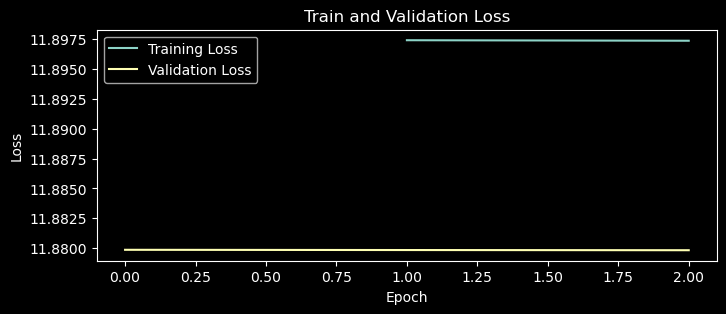

# Epoch: 0  (Before start training) 
# Evaluating on Validation Dateset: # Validation loss: 11.91 
# Epoch: 1 (Learning rate: 2e-05)  Training loss: 11.90 || Validation loss: 11.91
# Epoch: 2 (Learning rate: 2e-05)  Training loss: 11.90 || Validation loss: 11.91
{'train_results': [[11.902143478393555, 11.902103424072266]], 'validation_results': [[11.911471366882324, 11.911456108093262, 11.9114408493042]]}


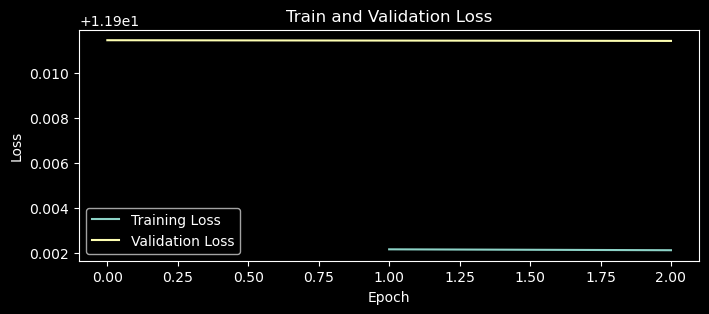

All Scouts Training End.

time: 1min 18s (started: 2024-09-04 12:27:35 +03:00)


In [106]:
# num_labels = 10 #already defined in whe crating reference BERT_Classification_model
NB_SCOUTS = 2
EPOCHS = 2
PATIENCE = 2
BATCH_SIZE = 8
LOSS_FUNCTION = nn.CrossEntropyLoss()  # Combines the softmax activation function and the negative log-likelihood loss in a single operation
LEARNING_RATE = 2e-5
MAX_LENGTH = 128
ITEMS_FROM_SUBEST_NB = 5


print("Start Training Scouts:\n")
for _ in range(NB_SCOUTS):
    # add train and validation to the dataset : 
    dataset = load_dataset("NeelNanda/pile-10k", split={'train': 'train[:80%]', 'validation': 'train[80%:]'})  

    train_dataset = dataset['train'][:ITEMS_FROM_SUBEST_NB]
    val_dataset = dataset['validation'][:ITEMS_FROM_SUBEST_NB]
    
    thepile_custom_train_subset = CustomDataset(train_dataset['text'],tokenizer=llama3_tokenizer,max_length=MAX_LENGTH )
    thepile_custom_val_subset = CustomDataset(val_dataset['text'],tokenizer=llama3_tokenizer,max_length=MAX_LENGTH )

    train_dataloader = DataLoader(thepile_custom_train_subset, batch_size=BATCH_SIZE, collate_fn=collate_fn, shuffle=True)
    val_dataloader = DataLoader(thepile_custom_val_subset, batch_size=BATCH_SIZE, collate_fn=collate_fn, shuffle=True)
    simple_llama3_scout = SimpleLlama(vocab_size, embed_dim, num_heads, num_layers, ff_hidden_dim).to(DEVICE)
    
    print('================================================================')
    losses = train_model(simple_llama3_scout,
                         optimizer=AdamW(simple_llama3_scout.parameters(),lr=LEARNING_RATE),
                         epochs=EPOCHS,
                         train_loader=train_dataloader,
                         validation_loader=val_dataloader,
                         train_verbose=True, 
                         eval_verbose=True,
                         with_early_stopping=False,
                         with_autocast=False, #cannot use autocast when the model is downloaded in bfloat16
                         with_lr_sceduler=False,                                 
                        )
    print(losses)
    plot_results(losses)

    llama3_scouts.add_scout(simple_llama3_scout) 

print(f"All Scouts Training End.\n=============================================================\n")



In [107]:
# Create the guidance matrix from the scouts:
simplellama3_raw_guidance_matrix = llama3_scouts.create_raw_guidance(DEVICE) 

time: 0 ns (started: 2024-09-04 12:28:57 +03:00)


In [108]:
gtl.save_guidance_matrix(simplellama3_raw_guidance_matrix, name='simplellama3_raw_guidance_matrix.pt') 

WindowsPath('c:/Users/user/Desktop/My_Files/Anaconda  Projects/DevTechPro/Notebooks/Guided Transfer Learning-DevTech/guided_transfer_learning_library/simplellama3_raw_guidance_matrix.pt')

time: 15 ms (started: 2024-09-04 12:28:58 +03:00)


In [100]:
dataset = load_dataset("wikitext", "wikitext-103-raw-v1", split={'train': 'train[:80%]', 'validation': 'train[80%:]'}) 


time: 16.3 s (started: 2024-09-04 12:25:05 +03:00)


In [109]:
dataset['train'][5]

{'text': "Q:\n\nWhy was Mundungus banned from the Hog's Head?\n\nIn Order of the Phoenix while the trio were in the Hogs Head for the first time plotting the start of Dumbledore's Army, it transpires that ol' Dung was lurking in the pub in a disguise, having been banned 20 years previously according to Sirius. \nFirstly, why was he banned? this could possibly be the tight spot that Albus had helped Dung with in the first place that made him loyal to Albus.  \nAnd secondly, how is it that he is then speaking to Aberforth in Halfblood Prince? (assuming the ban was for something rather unforgivable, 20 years is a long time?) \nThey both could have been in the Order by then, but unlikely given Aberforth's attitude in Deathly Hallows once the trio arrive in Hogsmeade looking for the tiara.  We learn now that a lot of trafficking goes on through the Hogs Head so maybe Dung was trading with Aberforth, Sirius' mirror and various other Black artifacts, he just was not allowed in the pub. \nAnyo

time: 0 ns (started: 2024-09-04 12:29:11 +03:00)


# Llama-3 Reference Model loaded.
# Epoch: 0  (Before start training) 
# Evaluating on Validation Dateset: # Validation loss: 11.65 
# Epoch: 1 (Learning rate: 2e-05)  Training loss: nan || Validation loss: 11.65
{'train_results': [[nan]], 'validation_results': [[11.645781517028809, 11.645781517028809]]}


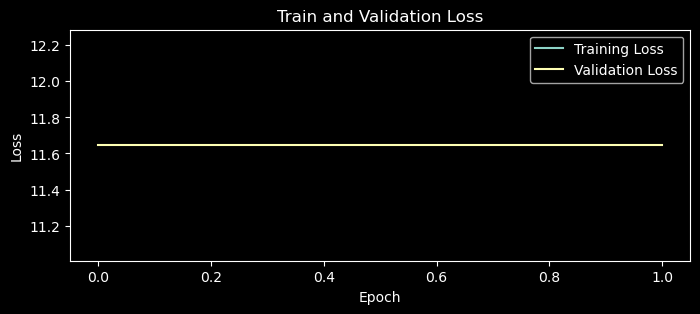

time: 28.3 s (started: 2024-09-04 12:30:36 +03:00)


In [110]:
##  Take one or more  items fron wikitext for Few-shot learn:
NUM_SAMPLES = 1
EPOCHS = 1
BATCH_SIZE = 8
LOSS_FUNCTION = nn.CrossEntropyLoss()  # Combines the softmax activation function and the negative log-likelihood loss in a single operation
LEARNING_RATE = 2e-5
MAX_LENGTH = 128
ITEMS_FROM_SUBEST_NB = 5


dataset = load_dataset("wikitext", "wikitext-103-raw-v1", split={'train': 'train[:80%]', 'validation': 'train[80%:]'}) 

wikitext_train_dataset = dataset['train'][:NUM_SAMPLES]
wikitext_val_dataset = dataset['validation'][:NUM_SAMPLES]

wikitext_custom_dataset = CustomDataset(wikitext_train_dataset['text'], tokenizer=llama3_tokenizer,max_length=MAX_LENGTH )
wikitext_val_dataset = CustomDataset(wikitext_val_dataset['text'],tokenizer=llama3_tokenizer,max_length=MAX_LENGTH )

# Create DataLoaders
train_dataloader = DataLoader(wikitext_custom_dataset, batch_size=BATCH_SIZE, collate_fn=collate_fn, shuffle=True)
val_dataloader = DataLoader(wikitext_val_dataset, batch_size=BATCH_SIZE,collate_fn=collate_fn, shuffle=True)

# Load reference model:
# llama3_model.load_state_dict(torch.load(reference_model_path))

simple_llama3_model = SimpleLlama(vocab_size, embed_dim, num_heads, num_layers, ff_hidden_dim).to(DEVICE)


print(f"# Llama-3 Reference Model loaded.") 
# train model (not intersted in results: _)
print('================================================================')

simple_llama_3_losses = train_model(simple_llama3_model,
                             optimizer=AdamW(simple_llama3_model.parameters(),lr=LEARNING_RATE),
                             epochs=EPOCHS,
                             train_loader=train_dataloader,
                             validation_loader=val_dataloader,
                             train_verbose=True, 
                             eval_verbose=True,
                             with_GTL=True,
                             guidance_matrix=simplellama3_raw_guidance_matrix,
                             with_autocast=False, 
                             with_lr_sceduler=False
                             )

print(simple_llama_3_losses) 
plot_results(simple_llama_3_losses) 

In [111]:
torch.save(simple_llama3_model, 'few-shot-learn-trained-model.pt')

time: 47 ms (started: 2024-09-04 12:31:45 +03:00)


In [ ]:
bnb_config = BitsAndBytesConfig( 
    load_in_4bit=True,
#     bnb_4bit_use_double_quant=True,
#     bnb_4bit_quant_type="nf4", #4bit Normal Float
#     bnb_4bit_compute_dtype=torch.bfloat16
    
#     bnb_4bit_compute_dtype=torch.float32  # Switch to FP16
)

In [83]:
epochs = 1 
lr_train = 5e-5
optimizer=AdamW(llama3_model.parameters(),lr=lr_train)

llama_3_losses = train_model(llama3_model,
                             optimizer=AdamW(llama3_model.parameters(),lr=lr_train),
                             epochs=epochs,
                             train_loader=train_dataloader,
                             validation_loader=val_dataloader, 
                             patience=2,                                               
                             train_verbose=True, 
                             eval_verbose=True,
                             with_autocast=False #cannot use autocast when the model is quantized
                            ) 

# Epoch: 0  (Before start training) 
# Evaluating on Validation Dateset: # Validation loss: 3.12 
# Epoch: 1 (Learning rate: 5e-05)  Training loss: nan || Validation loss: nan
time: 7min 25s (started: 2024-08-23 06:51:25 +00:00)


In [123]:
# Empty GPU cache
torch.cuda.empty_cache() 

time: 180 ms (started: 2024-08-23 08:18:02 +00:00)


##### The pile dataset

In [ ]:
### With Streaming:

# num_samples_to_take = 1000
# dataset_name = "EleutherAI/pile"
# thepile_ds = load_dataset(dataset_name, 'enron_emails', split="train", streaming=True) # subsets: ['all', 'enron_emails', 'europarl', 'free_law', 'hacker_news', 'nih_exporter', 'pubmed', 'pubmed_central', 'ubuntu_irc', 'uspto', 'github']
# thepile_ds = thepile_ds.take(num_samples_to_take)

### thepile_ds is not a dataset, but an iterable dataset, we should deal with it accordingly. 

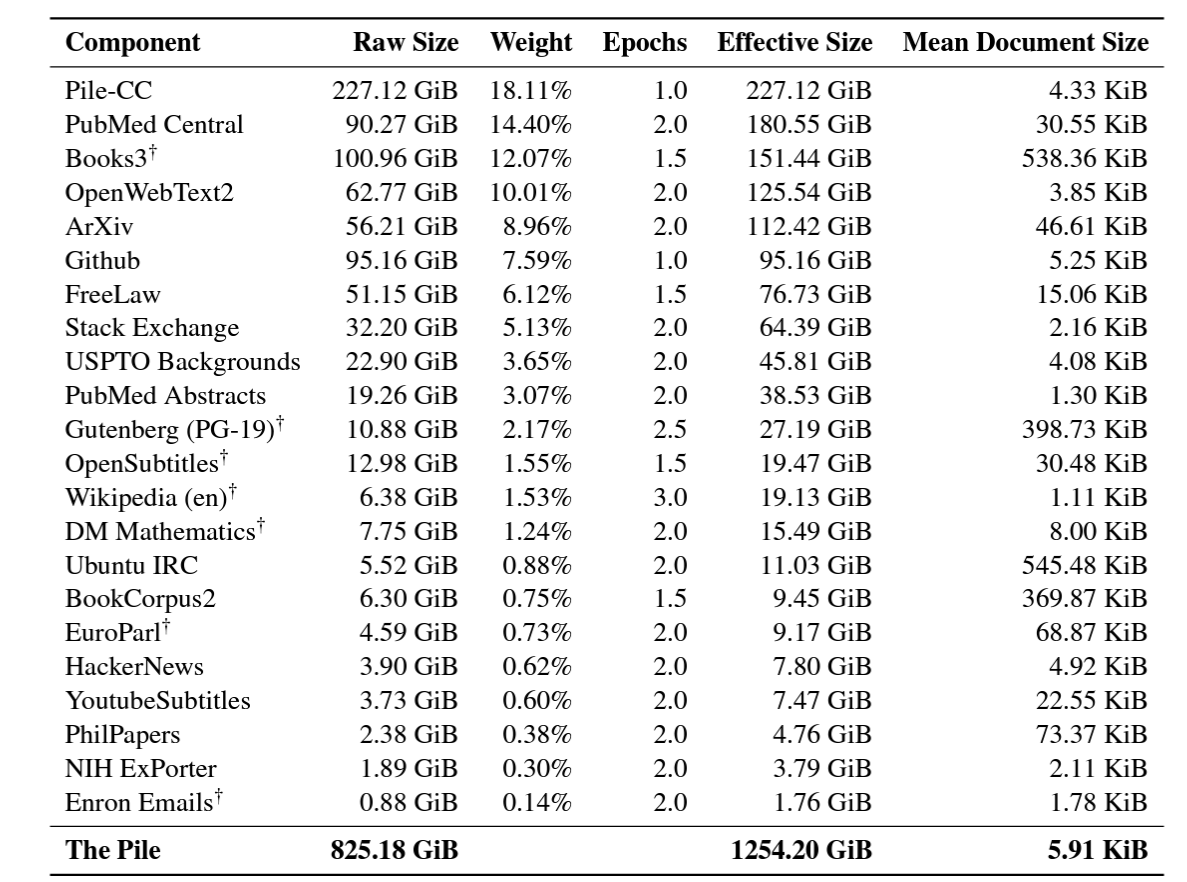

https://arxiv.org/abs/2101.00027

In [47]:
from datasets import get_dataset_config_names

# Get all subsets of The Pile dataset
dataset_name = "EleutherAI/pile"
thepile_subsets = get_dataset_config_names(dataset_name)

# Print all available subsets
print(thepile_subsets)

c:\Users\user\Anaconda3\envs\torch-env\Lib\site-packages\datasets\load.py:1486: FutureWarning: The repository for EleutherAI/pile contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/EleutherAI/pile
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this dataset from the next major release of `datasets`.
  warnings.warn(


['all', 'enron_emails', 'europarl', 'free_law', 'hacker_news', 'nih_exporter', 'pubmed', 'pubmed_central', 'ubuntu_irc', 'uspto', 'github']
time: 6.48 s (started: 2024-09-04 11:52:16 +03:00)


In [ ]:
dataset_name = "EleutherAI/pile"
thepile_subset = load_dataset(dataset_name, 'enron_emails') 
# ['all', 'enron_emails', 'europarl', 'free_law', 'hacker_news', 'nih_exporter', 'pubmed', 'pubmed_central', 'ubuntu_irc', 'uspto', 'github']


In [69]:
thepile_subset

DatasetDict({
    train: Dataset({
        features: ['text', 'meta'],
        num_rows: 517401
    })
})

time: 2.94 ms (started: 2024-08-23 10:53:27 +00:00)


In [85]:
# Print random item from the dataset
print(thepile_subset['train'][random.randint(0,9999)]['text']) # type: ignore

Message-ID: <23659994.1075863597886.JavaMail.evans@thyme>
Date: Mon, 3 Jul 2000 06:36:00 -0700 (PDT)
From: robert.badeer@enron.com
To: mbelden@mediaone.com
Subject: Price Cap Graphs
Mime-Version: 1.0
Content-Type: text/plain; charset=us-ascii
Content-Transfer-Encoding: 7bit
X-From: Robert Badeer
X-To: mbelden@mediaone.com
X-cc: 
X-bcc: 
X-Folder: \Robert_Badeer_Aug2000\Notes Folders\Discussion threads
X-Origin: Badeer-R
X-FileName: rbadeer.nsf

---------------------- Forwarded by Robert Badeer/HOU/ECT on 07/03/2000 01:39 
PM ---------------------------

06/30/2000 05:08 PM
Cooper Richey
Cooper Richey
Cooper Richey
06/30/2000 05:08 PM
06/30/2000 05:08 PM
To: David Parquet/SF/ECT@ECT
cc: Robert Badeer/HOU/ECT@ECT, Tim Belden/HOU/ECT@ECT 
Subject: Price Cap Graphs

Dave,

Here is the next cut,  

I've listed assumptions and added the regulation to the ancillary service 
component







time: 854 µs (started: 2024-08-23 11:03:30 +00:00)


In [81]:
# Number of samples to take
num_samples = 10000

# Subset the dataset
thepile_subset_mini = thepile_subset['train'].select(range(num_samples)) 

time: 4.53 ms (started: 2024-08-23 10:58:16 +00:00)


In [88]:
thepile_subset_mini_custom = CustomDataset(
    thepile_subset_mini['text'],
    tokenizer=llama3_tokenizer,
    max_length= 128000)

train_dataloader = DataLoader(thepile_subset_mini_custom, batch_size=4, collate_fn=collate_fn, shuffle=True)
val_dataloader = DataLoader(thepile_subset_mini_custom, batch_size=4, collate_fn=collate_fn, shuffle=True)

time: 27.7 ms (started: 2024-08-23 11:04:01 +00:00)


In [89]:
epochs = 20 
lr_train = 5e-5
optimizer=AdamW(simple_llama3_model.parameters(),lr=lr_train)

llama_3_losses = train_model(simple_llama3_model,
                             optimizer=AdamW(simple_llama3_model.parameters(),lr=lr_train),
                             epochs=epochs,
                             train_loader=train_dataloader,
                             validation_loader=val_dataloader, 
                             patience=2,                                               
                             train_verbose=True, 
                             eval_verbose=True,
                             with_autocast=False #cannot use autocast when the model is downloaded in bfloat16
                            ) 

# Epoch: 0  (Before start training) 
# Evaluating on Validation Dateset: # Validation loss: 11.55 
# Epoch: 1 (Learning rate: 5e-05)  Training loss: 11.37 || Validation loss: 11.18
# Epoch: 5 (Learning rate: 5e-05)  Training loss: 9.51 || Validation loss: 9.24
# Epoch: 10 (Learning rate: 5e-05)  Training loss: 6.71 || Validation loss: 6.48
# Epoch: 15 (Learning rate: 5e-05)  Training loss: 5.35 || Validation loss: 5.31
# Epoch: 20 (Learning rate: 5e-05)  Training loss: 5.17 || Validation loss: 5.17
time: 37min 5s (started: 2024-08-23 11:04:02 +00:00)


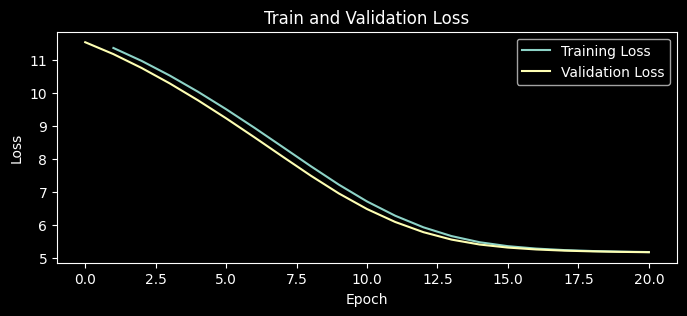

time: 327 ms (started: 2024-08-23 11:52:09 +00:00)


In [92]:
plot_results(llama_3_losses)

##### Create Reference Model

In [49]:
# Example usage
vocab_size = len(llama3_tokenizer)     #Real   Llama values # Example vocabulary size
embed_dim = 1         #4096   #Real Llama values  # Example embedding dimension
num_heads = 1           #64     # Number of attention heads
num_layers = 1          #60     # Number of transformer layers
ff_hidden_dim = 1     #4096   # Feed-forward hidden dimension

llama3_model = SimpleLlama(vocab_size, embed_dim, num_heads, num_layers, ff_hidden_dim).to(DEVICE)

time: 281 ms (started: 2024-09-04 11:54:58 +03:00)


In [ ]:
# Wrap the model with DataParallel to use multiple GPUs
# DataParallel will split the input data across available GPUs



In [ ]:
# Load the tokenizer and model
model_name = "meta-llama/Meta-Llama-3.1-8B"
llama3_model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto", token=HF_TOKEN)

In [ ]:
reference_model_path = 'C:/Users/user/Desktop/My_Files/Anaconda  Projects/data/Models/llama3_model_reference.pt'

In [ ]:
llama3_model= nn.DataParallel(llama3_model)

In [ ]:
# # Save the model's state dictionary
# torch.save(llama3_model.state_dict(), reference_model_path)

In [ ]:
llama3_model.load_state_dict(torch.load(reference_model_path))

##### Create Scouts and Guidance Matrix

In [50]:
llama3_scouts = gtl.create_scouts( llama3_model,should_save_guidance=False, should_save_scouts=False, use_squared_differences=True)
print("Scouts created")


Scouts created
time: 16 ms (started: 2024-09-04 11:55:14 +03:00)


- Train Scouts

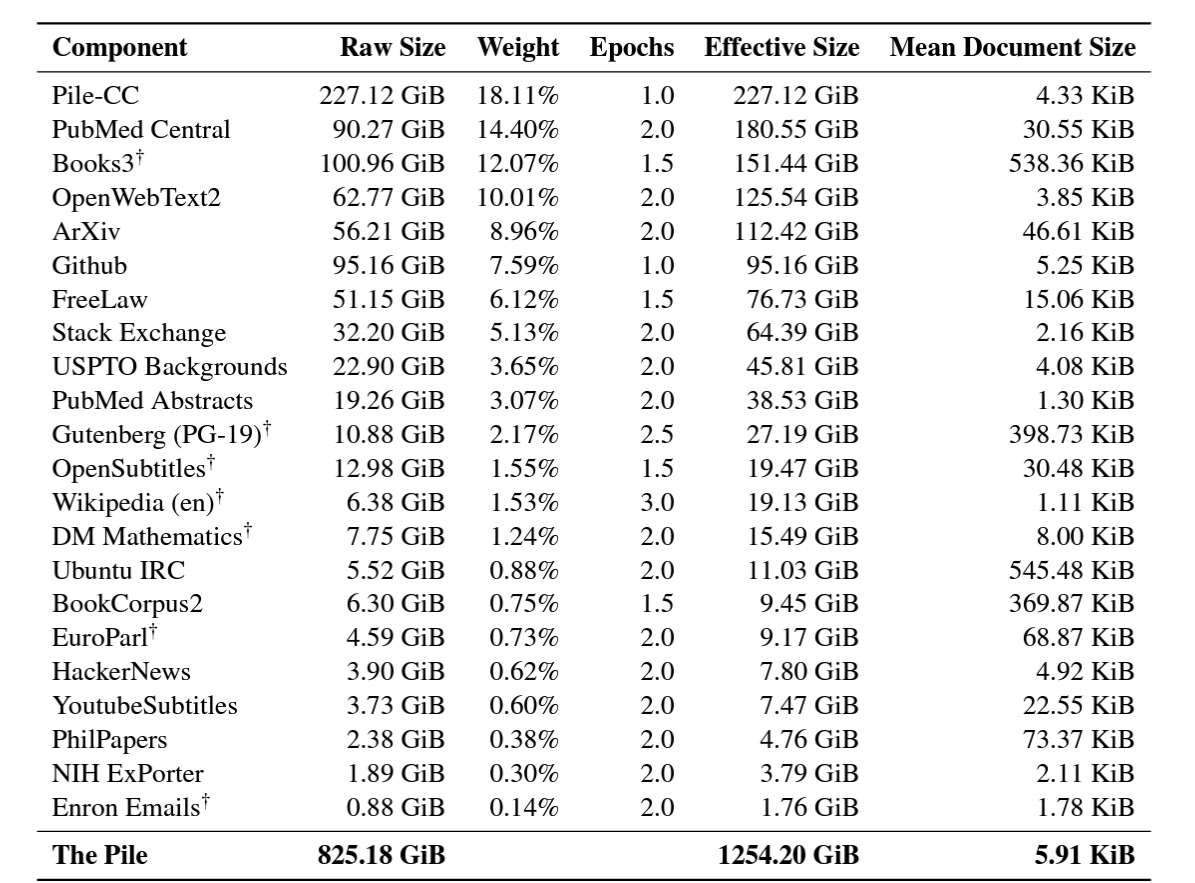

In [52]:
# Since we cannot download subsets of the pile from HF, we can download each subest from a different source directly:

thepile_datasets_links =['jacquelinehe/enron-emails', # 972 MB 
                         'amongglue/youtube_subtitles',  #1.96 GB
                         'jkeisling/hacker-news-corpus-2007-2022',# 2.97 GB
                        ] #'free_law', 'pubmed', 'pubmed_central',  'uspto', 'github']]



time: 0 ns (started: 2024-09-04 11:55:35 +03:00)


In [55]:
# num_labels = 10 #already defined in whe crating reference BERT_Classification_model
NB_SCOUTS = 1
EPOCHS = 1
PATIENCE = 2
BATCH_SIZE = 8
LOSS_FUNCTION = nn.CrossEntropyLoss()  # Combines the softmax activation function and the negative log-likelihood loss in a single operation
LEARNING_RATE = 2e-5
MAX_LENGTH = 128000
ITEMS_FROM_SUBEST_NB = 5

assert NB_SCOUTS <= len(thepile_datasets_links), "nb_scouts exceeds the length of the list."

print("Start Training Scouts:\n")
for subset_link in thepile_datasets_links[:NB_SCOUTS]:
    print(f"=============================================================\nScout for subset: {subset_link} Training Start:") 

    dataset = load_dataset("NeelNanda/pile-10k",split={'train': 'train[:80%]', 'validation': 'train[80%:]'}) 
    # dataset = load_dataset(subset_link, split={'train': 'train[:80%]', 'validation': 'train[80%:]'}) 
    # print(f"{subset_link} loaded.")
    
    train_dataset = dataset['train'][:ITEMS_FROM_SUBEST_NB]
    val_dataset = dataset['validation'][:ITEMS_FROM_SUBEST_NB]
    
    thepile_custom_train_subset = CustomDataset(train_dataset['text'],tokenizer=llama3_tokenizer,max_length=MAX_LENGTH )
    thepile_custom_val_subset = CustomDataset(val_dataset['text'],tokenizer=llama3_tokenizer,max_length=MAX_LENGTH )

    train_dataloader = DataLoader(thepile_custom_train_subset, batch_size=BATCH_SIZE, collate_fn=collate_fn, shuffle=True)
    val_dataloader = DataLoader(thepile_custom_val_subset, batch_size=BATCH_SIZE, collate_fn=collate_fn, shuffle=True)
        
    # Load reference model:
#     simple_llama3_model.load_state_dict(torch.load(reference_model_path))

    print(f"# Llama-3 Reference Model loaded. Starting training model.") 
    # Load the tokenizer and model
    model_name = "meta-llama/Meta-Llama-3.1-8B"
    llama3_model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto", token=HF_TOKEN)

    
    print('================================================================')
    losses = train_model(llama3_model,
                         optimizer=AdamW(llama3_model.parameters(),lr=LEARNING_RATE),
                         epochs=EPOCHS,
                         train_loader=train_dataloader,
                         validation_loader=val_dataloader,
                         train_verbose=True, 
                         eval_verbose=True,
                         with_early_stopping=False,
                         with_autocast=False, #cannot use autocast when the model is downloaded in bfloat16
                         with_lr_sceduler=False,                                 
                        )
    print(losses)
    plot_results(losses)

    print(f"\n# Scout  {subset_link} Training End.\n=============================================================\n")    
    llama3_scouts.add_scout(llama3_model)  
       
    del dataset
    del llama3_model

print(f"All Scouts in [ {thepile_datasets_links} ]  Training End.\n=============================================================\n")



Start Training Scouts:

Scout for subset: jacquelinehe/enron-emails Training Start:
# Llama-3 Reference Model loaded. Starting training model.


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

ValueError: You are trying to offload the whole model to the disk. Please use the `disk_offload` function instead.

time: 5.97 s (started: 2024-09-04 12:03:02 +03:00)


In [ ]:
# Create the guidance matrix from the scouts:
llama3_raw_guidance_matrix = llama3_scouts.create_raw_guidance(DEVICE) 


In [ ]:
gtl.save_guidance_matrix(llama3_raw_guidance_matrix, name='llama3_raw_guidance_matrix.pt') 

In [ ]:
gtl.plot_guidance_distribution(llama3_raw_guidance_matrix)

- Rescale Guidance Matrix

In [ ]:
llama3_rescaled_guidance_matrix = llama3_raw_guidance_matrix.copy() 
def rescale_matrix_layer_by_layer(matrix):
    for layer in matrix:
        min_layer = torch.amin(matrix[layer])
        max_layer = torch.amax(matrix[layer])
        scale =  1/(max_layer - min_layer)
        if scale is not torch.inf:
            matrix[layer] = scale *  matrix[layer]
            
rescale_matrix_layer_by_layer(llama3_rescaled_guidance_matrix)
llama3_rescaled_guidance_matrix


##### Train With GTL: Few-Show Learn

In [ ]:
# texts = [
#     "In the serene countryside, the golden rays of the sun danced upon the lush green fields, painting a picturesque scene. The gentle breeze carried the sweet scent of blooming flowers, while birds chirped melodiously, creating a symphony of nature. The tranquil river flowed gracefully, reflecting the clear blue sky. A lone fisherman sat by the riverbank, casting his line with patience, his thoughts drifting like the clouds above. Children played nearby, their laughter echoing through the valley. It was a perfect day, where time seemed to stand still in nature's embrace.",
#     "On a bustling city street, cars honked and people rushed by, each engrossed in their own world. The towering skyscrapers cast long shadows on the pavement below, where vendors sold their wares to passersby. A street musician played a soulful tune on his guitar, his music weaving through the noise of the city. A group of friends gathered at a nearby café, sharing stories and laughter over cups of steaming coffee. Despite the chaos, there was a sense of community, of lives intersecting in this vibrant urban jungle, each with a story to tell.",
#     "In a quiet library, the scent of old books filled the air, and the only sounds were the soft rustling of pages and the occasional whisper. Sunlight streamed through tall windows, casting a warm glow on the rows of bookshelves that lined the walls. A young student sat at a wooden table, deeply engrossed in a thick novel, his eyes scanning the pages with curiosity. Nearby, an elderly man browsed the history section, his fingers tracing the spines of ancient tomes. It was a sanctuary of knowledge, where time slowed down and minds could wander freely.",
#     "At the edge of a dense forest, a small cabin stood nestled among the trees, its wooden walls weathered by years of enduring the elements. Smoke curled lazily from the chimney, hinting at the warmth within. Inside, a fire crackled in the hearth, casting flickering shadows on the walls. A woman sat by the window, knitting a woolen scarf, her mind wandering to distant memories. Outside, a deer grazed near the treeline, its ears twitching at the slightest sound. The world seemed distant here, where nature's embrace offered solace and a connection to the earth.",
#    ]


In [ ]:
# Empty GPU cache
torch.cuda.empty_cache()

In [ ]:
##  Take one or more  items fron wikitext for Few-shot learn:
NUM_SAMPLES = 1
# num_labels = 10 #already defined in whe crating reference BERT_Classification_model
NB_SCOUTS = 3
EPOCHS = 1
BATCH_SIZE = 8
LOSS_FUNCTION = nn.CrossEntropyLoss()  # Combines the softmax activation function and the negative log-likelihood loss in a single operation
LEARNING_RATE = 2e-5
MAX_LENGTH = 128000
ITEMS_FROM_SUBEST_NB = 100


dataset = load_dataset("wikitext", "wikitext-103-raw-v1", split={'train': 'train[:80%]', 'validation': 'train[80%:]'}) 

wikitext_train_dataset = dataset['train'][:NUM_SAMPLES]
wikitext_val_dataset = dataset['validation'][:NUM_SAMPLES]

wikitext_custom_dataset = CustomDataset(wikitext_train_dataset['text'], tokenizer=llama3_tokenizer,max_length=MAX_LENGTH )
wikitext_val_dataset = CustomDataset(wikitext_val_dataset['text'],tokenizer=llama3_tokenizer,max_length=MAX_LENGTH )

# Create DataLoaders
train_dataloader = DataLoader(wikitext_custom_dataset, batch_size=BATCH_SIZE, collate_fn=collate_fn, shuffle=True)
val_dataloader = DataLoader(wikitext_val_dataset, batch_size=BATCH_SIZE,collate_fn=collate_fn, shuffle=True)

# Load reference model:
# llama3_model.load_state_dict(torch.load(reference_model_path))

model_name = "meta-llama/Meta-Llama-3.1-8B"
llama3_model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto", token=HF_TOKEN)



llama3_model= nn.DataParallel(llama3_model)




print(f"# Llama-3 Reference Model loaded.") 
# train model (not intersted in results: _)
print('================================================================')

llama_3_losses = train_model(llama3_model,
                             optimizer=AdamW(llama3_model.parameters(),lr=LEARNING_RATE),
                             epochs=EPOCHS,
                             train_loader=train_dataloader,
                             validation_loader=val_dataloader,
                             train_verbose=True, 
                             eval_verbose=True,
                             with_GTL=True,
                             guidance_matrix=llama3_rescaled_guidance_matrix,
                             with_autocast=False, # Cannot use autocast when the model is downloaded in bfloat16
                             with_lr_sceduler=False
                             )

print(llama_3_losses) 
plot_results(llama_3_losses) 

##### Train Without GTL: Few-Shot Learn


In [ ]:
# Empty GPU cache
torch.cuda.empty_cache()

In [13]:
##  Take one or more  items fron wikitext for Few-shot learn:
NUM_SAMPLES = 1
# num_labels = 10 #already defined in whe crating reference BERT_Classification_model
NB_SCOUTS = 3
EPOCHS = 1
BATCH_SIZE = 8
LOSS_FUNCTION = nn.CrossEntropyLoss()  # Combines the softmax activation function and the negative log-likelihood loss in a single operation
LEARNING_RATE = 2e-5
MAX_LENGTH = 32
ITEMS_FROM_SUBEST_NB = 100


dataset = load_dataset("wikitext", "wikitext-103-raw-v1", split={'train': 'train[:80%]', 'validation': 'train[80%:]'}) 

wikitext_train_dataset = dataset['train'][:NUM_SAMPLES]
wikitext_val_dataset = dataset['validation'][:NUM_SAMPLES]

wikitext_custom_dataset = CustomDataset(wikitext_train_dataset['text'], tokenizer=llama3_tokenizer,max_length=MAX_LENGTH )
wikitext_val_dataset = CustomDataset(wikitext_val_dataset['text'],tokenizer=llama3_tokenizer,max_length=MAX_LENGTH )

# Create DataLoaders
train_dataloader = DataLoader(wikitext_custom_dataset, batch_size=BATCH_SIZE, collate_fn=collate_fn, shuffle=True)
val_dataloader = DataLoader(wikitext_val_dataset, batch_size=BATCH_SIZE,collate_fn=collate_fn, shuffle=True)

# Load reference model:
# llama3_model.load_state_dict(torch.load(reference_model_path))

model_name = "meta-llama/Meta-Llama-3.1-8B"
llama3_model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto", token=HF_TOKEN)


###############################################################################################################################


llama3_model= nn.DataParallel(llama3_model)

###############################################################################################################################




print(f"# Llama-3 Reference Model loaded.") 
print('================================================================')
llama_3_losses = train_model(llama3_model,
                             optimizer=AdamW(llama3_model.parameters(),lr=LEARNING_RATE),
                             epochs=EPOCHS,
                             train_loader=train_dataloader,
                             validation_loader=val_dataloader,
                             train_verbose=True, 
                             eval_verbose=True,
                             with_GTL=False,
                             with_autocast=False # Cannot use autocast when the model is downloaded in bfloat16
                             with_lr_sceduler=False
                             )

print(llama_3_losses) 
plot_results(llama_3_losses) 

SyntaxError: invalid syntax. Perhaps you forgot a comma? (1465019152.py, line 44)